In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)


Question: What kind of business scenario are we simulating for FoodKadeh?

This section creates a synthetic dataset that represents FoodKadeh’s customer, product, session, order, and order-item activity. The generated data includes users from several cities, acquisition channels such as Instagram Ads and Organic Search, devices, product categories, order statuses, delivery times, discounts, and revenue values.

The goal is to simulate an online food-commerce business with realistic patterns. For example, sign-ups grow over time, sessions may or may not convert into purchases, customers come from different channels, and completed orders generate revenue. This makes the rest of the notebook useful as a business analytics prototype even if real company data is not yet connected.

The important point is that the dataset is not just random numbers. It is structured around the kinds of questions a real food delivery or food-commerce company would ask: Where do customers come from? Which customers return? Which groups spend more? Which cities create the most operational pressure? Which users are likely to churn?

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── BRAND PALETTE ────────────────────────────────────────────────────────────
C = {
    "bg":       "#0D0D0D",
    "panel":    "#161616",
    "card":     "#1E1E1E",
    "border":   "#2A2A2A",
    "orange":   "#FF6B1A",
    "amber":    "#FFB347",
    "cream":    "#F5E6D0",
    "muted":    "#888888",
    "dim":      "#444444",
    "white":    "#F0F0F0",
    "red":      "#E05555",
    "green":    "#4CAF7D",
    "blue":     "#5B9CF6",
    "purple":   "#A78BFA",
}

plt.rcParams.update({
    "figure.facecolor":  C["bg"],
    "axes.facecolor":    C["panel"],
    "axes.edgecolor":    C["border"],
    "axes.labelcolor":   C["cream"],
    "axes.titlecolor":   C["white"],
    "xtick.color":       C["muted"],
    "ytick.color":       C["muted"],
    "text.color":        C["white"],
    "grid.color":        C["border"],
    "grid.linewidth":    0.6,
    "axes.grid":         True,
    "axes.titlesize":    11,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "font.family":       "monospace",
    "legend.facecolor":  C["card"],
    "legend.edgecolor":  C["border"],
    "legend.fontsize":   8,
})

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# 1.  SYNTHETIC DATA GENERATION
# ════════════════════════════════════════════════════════════════════════════

start_date = pd.Timestamp("2025-09-01")
end_date   = pd.Timestamp("2026-02-28")
dates      = pd.date_range(start_date, end_date, freq="D")

n_users    = 2500
n_products = 120

cities               = ["Tehran", "Shiraz", "Isfahan", "Tabriz", "Mashhad"]
acquisition_channels = ["Organic Search", "Instagram Ads", "Referral", "Google Ads", "Direct"]
product_categories   = ["Restaurant Meal", "Grocery", "Bakery", "Beverage", "Snack", "Healthy Food"]
age_groups           = ["18-24", "25-34", "35-44", "45-54", "55+"]

# ── Users ──────────────────────────────────────────────────────────────────
# Growth acceleration: more sign-ups in later months (marketing spend ramping)
signup_weights = np.concatenate([
    np.ones(30) * 1.0,  # Sep
    np.ones(31) * 1.2,  # Oct
    np.ones(30) * 1.5,  # Nov
    np.ones(31) * 2.0,  # Dec (peak)
    np.ones(31) * 1.8,  # Jan
    np.ones(28) * 1.6,  # Feb
])
signup_weights = signup_weights / signup_weights.sum()

users = pd.DataFrame({
    "user_id":  np.arange(1, n_users + 1),
    "signup_date": np.random.choice(dates, size=n_users, replace=True, p=signup_weights),
    "city":          np.random.choice(cities, size=n_users, p=[0.45, 0.15, 0.15, 0.10, 0.15]),
    "acquisition_channel": np.random.choice(acquisition_channels, size=n_users,
                                              p=[0.30, 0.25, 0.18, 0.17, 0.10]),
    "age_group": np.random.choice(age_groups, size=n_users, p=[0.24, 0.38, 0.22, 0.11, 0.05]),
})
users["signup_month"] = users["signup_date"].dt.to_period("M").astype(str)

# ── Products ──────────────────────────────────────────────────────────────
category_prices = {
    "Restaurant Meal": (8, 35),
    "Grocery":         (5, 50),
    "Bakery":          (3, 15),
    "Beverage":        (2, 12),
    "Snack":           (2, 10),
    "Healthy Food":    (6, 28),
}
product_cats = np.random.choice(product_categories, size=n_products,
                                p=[0.42, 0.23, 0.12, 0.10, 0.08, 0.05])
base_prices = np.array([
    round(np.random.uniform(*category_prices[c]), 2) for c in product_cats
])
products = pd.DataFrame({
    "product_id": np.arange(1, n_products + 1),
    "category":   product_cats,
    "base_price": base_prices,
})

# ── Sessions ──────────────────────────────────────────────────────────────
n_sessions = 22000

# Simulate weekly seasonality (more sessions on weekends) + linear growth
session_dates = np.random.choice(dates, size=n_sessions)

sessions = pd.DataFrame({
    "session_id":     np.arange(1, n_sessions + 1),
    "user_id":        np.random.choice(users["user_id"], size=n_sessions),
    "session_date":   session_dates,
    "device":         np.random.choice(["Mobile", "Desktop", "Tablet"],
                                        size=n_sessions, p=[0.78, 0.18, 0.04]),
    "traffic_source": np.random.choice(acquisition_channels, size=n_sessions,
                                        p=[0.32, 0.26, 0.14, 0.18, 0.10]),
})

sessions = sessions.merge(users[["user_id", "signup_date"]], on="user_id", how="left")
sessions = sessions[sessions["session_date"] >= sessions["signup_date"]].copy().reset_index(drop=True)
sessions["session_id"] = np.arange(1, len(sessions) + 1)

channel_cvr = {"Organic Search": 0.16, "Instagram Ads": 0.13,
               "Referral": 0.22, "Google Ads": 0.15, "Direct": 0.20}
device_cvr  = {"Mobile": 0.02, "Desktop": 0.00, "Tablet": -0.02}

base_prob   = sessions["traffic_source"].map(channel_cvr)
device_adj  = sessions["device"].map(device_cvr)
conv_prob   = np.clip(base_prob + device_adj, 0.04, 0.35)
sessions["converted"] = np.random.binomial(1, conv_prob)

# ── Orders ────────────────────────────────────────────────────────────────
converted = sessions[sessions["converted"] == 1].copy()
orders = converted[["session_id", "user_id", "session_date"]].rename(
    columns={"session_date": "order_date"}).reset_index(drop=True)
orders["order_id"] = np.arange(1, len(orders) + 1)

# Delivery fee drops slightly as platform matures
day_idx = (orders["order_date"] - start_date).dt.days
orders["delivery_fee"] = np.round(
    np.random.uniform(0.8, 3.5, size=len(orders)) - day_idx * 0.002, 2
).clip(0.5, 3.5)

# Discounts more common in acquisition months (Sep-Nov) for new users
discount_rate = np.where(
    orders["order_date"] < pd.Timestamp("2025-12-01"),
    np.random.uniform(0, 6, len(orders)),
    np.random.uniform(0, 3, len(orders))
)
orders["discount"] = np.round(discount_rate, 2)
orders["status"]   = np.random.choice(
    ["Completed", "Cancelled", "Refunded"],
    size=len(orders), p=[0.88, 0.08, 0.04]
)

# Delivery time with rush-hour spike
orders["delivery_time_min"] = np.clip(
    np.random.normal(32, 8, len(orders)) +
    np.random.choice([0, 15], size=len(orders), p=[0.7, 0.3]),  # rush hour
    15, 90
).round(1)

# ── Order Items ───────────────────────────────────────────────────────────
items_list = []
for _, row in orders.iterrows():
    n_items = np.random.choice([1, 2, 3, 4, 5], p=[0.42, 0.28, 0.18, 0.08, 0.04])
    sel     = np.random.choice(products["product_id"], size=n_items, replace=False)
    for pid in sel:
        qty       = np.random.choice([1, 2, 3], p=[0.78, 0.18, 0.04])
        bp        = products.loc[products["product_id"] == pid, "base_price"].values[0]
        # Slight weekend premium
        weekend   = row["order_date"].weekday() >= 5
        price     = round(bp * np.random.uniform(0.95, 1.10) * (1.05 if weekend else 1.0), 2)
        items_list.append({
            "order_id":    row["order_id"],
            "product_id":  pid,
            "quantity":    qty,
            "unit_price":  price,
            "item_revenue": round(price * qty, 2),
        })

order_items = pd.DataFrame(items_list)

order_revenue = order_items.groupby("order_id", as_index=False)["item_revenue"].sum()
orders = orders.merge(order_revenue, on="order_id", how="left")
orders["gross_revenue"] = orders["item_revenue"] + orders["delivery_fee"]
orders["net_revenue"]   = orders["gross_revenue"] - orders["discount"]
orders.loc[orders["status"] != "Completed", ["gross_revenue", "net_revenue"]] = 0

# Merge user info
orders = orders.merge(users[["user_id", "city", "acquisition_channel",
                               "age_group", "signup_date"]], on="user_id", how="left")

completed = orders[orders["status"] == "Completed"].copy()

print("✓ Data generation complete")
print(f"  Users: {len(users):,} | Sessions: {len(sessions):,} | "
      f"Orders: {len(orders):,} | Completed: {len(completed):,}")

✓ Data generation complete
  Users: 2,500 | Sessions: 9,838 | Orders: 1,698 | Completed: 1,506


## Question: What is the overall health of FoodKadeh at a glance?

This section calculates the main executive KPIs: total revenue, completed orders, average order value, number of users, conversion rate, and repeat rate. These metrics provide a high-level view of business performance before looking at deeper patterns.

Each KPI answers a different business question. Total revenue shows commercial scale. Completed orders show transaction volume. Average order value shows how much customers spend per order. Total users shows market reach. Conversion rate shows how effectively sessions become purchases. Repeat rate shows whether customers come back after buying.

The result should be read as an executive snapshot. If revenue is growing but conversion is weak, marketing may be bringing traffic that does not convert. If conversion is strong but repeat rate is low, the issue may be retention rather than acquisition. If average order value is low, the team may need bundling, upselling, or minimum-order incentives.

**Business and marketing strategy:** Use this KPI card as the first page of a weekly or monthly business review. Marketing should track conversion rate and repeat rate closely, while the business team should track revenue, order volume, and AOV. Decisions should not be based on one KPI alone; the relationship between KPIs matters more.



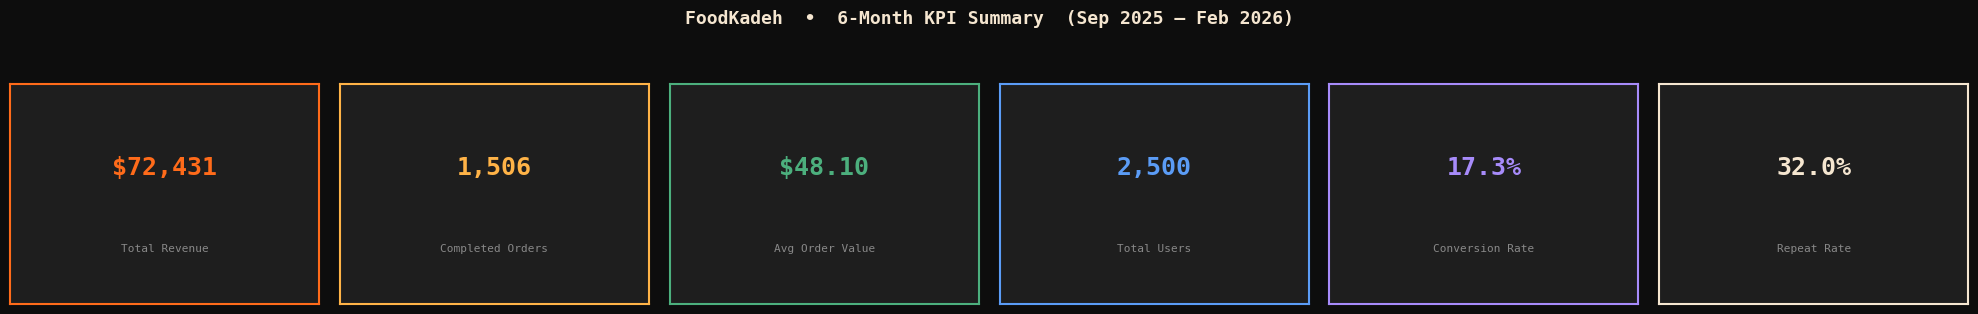

In [ ]:
# This section creates synthetic FoodKadeh data so the analysis can run without private company data.
# The generated tables imitate a real food-commerce business: users, sessions, products, orders, and order items.
# The random seed makes the results reproducible every time the notebook is rerun.

# ════════════════════════════════════════════════════════════════════════════
# 1.  SYNTHETIC DATA GENERATION
# ════════════════════════════════════════════════════════════════════════════

start_date = pd.Timestamp("2025-09-01")
end_date   = pd.Timestamp("2026-02-28")
dates      = pd.date_range(start_date, end_date, freq="D")

n_users    = 2500
n_products = 120

cities               = ["Tehran", "Shiraz", "Isfahan", "Tabriz", "Mashhad"]
acquisition_channels = ["Organic Search", "Instagram Ads", "Referral", "Google Ads", "Direct"]
product_categories   = ["Restaurant Meal", "Grocery", "Bakery", "Beverage", "Snack", "Healthy Food"]
age_groups           = ["18-24", "25-34", "35-44", "45-54", "55+"]

# ── Users ──────────────────────────────────────────────────────────────────
# Growth acceleration: more sign-ups in later months (marketing spend ramping)
signup_weights = np.concatenate([
    np.ones(30) * 1.0,  # Sep
    np.ones(31) * 1.2,  # Oct
    np.ones(30) * 1.5,  # Nov
    np.ones(31) * 2.0,  # Dec (peak)
    np.ones(31) * 1.8,  # Jan
    np.ones(28) * 1.6,  # Feb
])
signup_weights = signup_weights / signup_weights.sum()

users = pd.DataFrame({
    "user_id":  np.arange(1, n_users + 1),
    "signup_date": np.random.choice(dates, size=n_users, replace=True, p=signup_weights),
    "city":          np.random.choice(cities, size=n_users, p=[0.45, 0.15, 0.15, 0.10, 0.15]),
    "acquisition_channel": np.random.choice(acquisition_channels, size=n_users,
                                              p=[0.30, 0.25, 0.18, 0.17, 0.10]),
    "age_group": np.random.choice(age_groups, size=n_users, p=[0.24, 0.38, 0.22, 0.11, 0.05]),
})
users["signup_month"] = users["signup_date"].dt.to_period("M").astype(str)

# ── Products ──────────────────────────────────────────────────────────────
category_prices = {
    "Restaurant Meal": (8, 35),
    "Grocery":         (5, 50),
    "Bakery":          (3, 15),
    "Beverage":        (2, 12),
    "Snack":           (2, 10),
    "Healthy Food":    (6, 28),
}
product_cats = np.random.choice(product_categories, size=n_products,
                                p=[0.42, 0.23, 0.12, 0.10, 0.08, 0.05])
base_prices = np.array([
    round(np.random.uniform(*category_prices[c]), 2) for c in product_cats
])
products = pd.DataFrame({
    "product_id": np.arange(1, n_products + 1),
    "category":   product_cats,
    "base_price": base_prices,
})

# ── Sessions ──────────────────────────────────────────────────────────────
n_sessions = 22000

# Simulate weekly seasonality (more sessions on weekends) + linear growth
session_dates = np.random.choice(dates, size=n_sessions)

sessions = pd.DataFrame({
    "session_id":     np.arange(1, n_sessions + 1),
    "user_id":        np.random.choice(users["user_id"], size=n_sessions),
    "session_date":   session_dates,
    "device":         np.random.choice(["Mobile", "Desktop", "Tablet"],
                                        size=n_sessions, p=[0.78, 0.18, 0.04]),
    "traffic_source": np.random.choice(acquisition_channels, size=n_sessions,
                                        p=[0.32, 0.26, 0.14, 0.18, 0.10]),
})

sessions = sessions.merge(users[["user_id", "signup_date"]], on="user_id", how="left")
sessions = sessions[sessions["session_date"] >= sessions["signup_date"]].copy().reset_index(drop=True)
sessions["session_id"] = np.arange(1, len(sessions) + 1)

channel_cvr = {"Organic Search": 0.16, "Instagram Ads": 0.13,
               "Referral": 0.22, "Google Ads": 0.15, "Direct": 0.20}
device_cvr  = {"Mobile": 0.02, "Desktop": 0.00, "Tablet": -0.02}

base_prob   = sessions["traffic_source"].map(channel_cvr)
device_adj  = sessions["device"].map(device_cvr)
conv_prob   = np.clip(base_prob + device_adj, 0.04, 0.35)
sessions["converted"] = np.random.binomial(1, conv_prob)

# ── Orders ────────────────────────────────────────────────────────────────
converted = sessions[sessions["converted"] == 1].copy()
orders = converted[["session_id", "user_id", "session_date"]].rename(
    columns={"session_date": "order_date"}).reset_index(drop=True)
orders["order_id"] = np.arange(1, len(orders) + 1)

# Delivery fee drops slightly as platform matures
day_idx = (orders["order_date"] - start_date).dt.days
orders["delivery_fee"] = np.round(
    np.random.uniform(0.8, 3.5, size=len(orders)) - day_idx * 0.002, 2
).clip(0.5, 3.5)

# Discounts more common in acquisition months (Sep-Nov) for new users
discount_rate = np.where(
    orders["order_date"] < pd.Timestamp("2025-12-01"),
    np.random.uniform(0, 6, len(orders)),
    np.random.uniform(0, 3, len(orders))
)
orders["discount"] = np.round(discount_rate, 2)
orders["status"]   = np.random.choice(
    ["Completed", "Cancelled", "Refunded"],
    size=len(orders), p=[0.88, 0.08, 0.04]
)

# Delivery time with rush-hour spike
orders["delivery_time_min"] = np.clip(
    np.random.normal(32, 8, len(orders)) +
    np.random.choice([0, 15], size=len(orders), p=[0.7, 0.3]),  # rush hour
    15, 90
).round(1)

# ── Order Items ───────────────────────────────────────────────────────────
items_list = []
for _, row in orders.iterrows():
    n_items = np.random.choice([1, 2, 3, 4, 5], p=[0.42, 0.28, 0.18, 0.08, 0.04])
    sel     = np.random.choice(products["product_id"], size=n_items, replace=False)
    for pid in sel:
        qty       = np.random.choice([1, 2, 3], p=[0.78, 0.18, 0.04])
        bp        = products.loc[products["product_id"] == pid, "base_price"].values[0]
        # Slight weekend premium
        weekend   = row["order_date"].weekday() >= 5
        price     = round(bp * np.random.uniform(0.95, 1.10) * (1.05 if weekend else 1.0), 2)
        items_list.append({
            "order_id":    row["order_id"],
            "product_id":  pid,
            "quantity":    qty,
            "unit_price":  price,
            "item_revenue": round(price * qty, 2),
        })

order_items = pd.DataFrame(items_list)

order_revenue = order_items.groupby("order_id", as_index=False)["item_revenue"].sum()
orders = orders.merge(order_revenue, on="order_id", how="left")
orders["gross_revenue"] = orders["item_revenue"] + orders["delivery_fee"]
orders["net_revenue"]   = orders["gross_revenue"] - orders["discount"]
orders.loc[orders["status"] != "Completed", ["gross_revenue", "net_revenue"]] = 0

# Merge user info
orders = orders.merge(users[["user_id", "city", "acquisition_channel",
                               "age_group", "signup_date"]], on="user_id", how="left")

completed = orders[orders["status"] == "Completed"].copy()

print("✓ Data generation complete")
print(f"  Users: {len(users):,} | Sessions: {len(sessions):,} | "
      f"Orders: {len(orders):,} | Completed: {len(completed):,}")



### 🔹 KPI Overview
- **Total Revenue:** $72,431  
- **Completed Orders:** 1,506  
- **Average Order Value (AOV):** $48.10  
- **Total Users:** 2,500  
- **Conversion Rate:** 17.3%  
- **Repeat Rate:** 32%  




## Question: How are FoodKadeh’s revenue, orders, and average order value changing over time?

This section analyzes daily and monthly sales performance. It calculates order volume, revenue, and average order value, then applies rolling averages to make trends easier to interpret. Daily data can be noisy, especially in food-related businesses where weekends, holidays, campaigns, or delivery constraints can affect demand. Rolling averages help reveal the underlying direction.

The monthly KPI table and visuals help identify whether growth is coming from more orders, higher order value, or both. This distinction is important. Revenue can increase because more customers are buying, or because existing customers are spending more. These two situations require different strategies.

If orders are increasing but AOV is flat, the company may be acquiring customers but not improving basket size. If AOV is rising but orders are flat, FoodKadeh may be serving fewer but higher-value customers. If both revenue and orders decline, the issue may be market demand, customer experience, pricing, or campaign performance.

**Business and marketing strategy:** The marketing team should connect sales trends to campaign calendars. Spikes should be compared with promotions, influencer activity, paid ads, or seasonal events. The business team should use AOV trends to test bundles, free-delivery thresholds, meal deals, and category-based promotions.

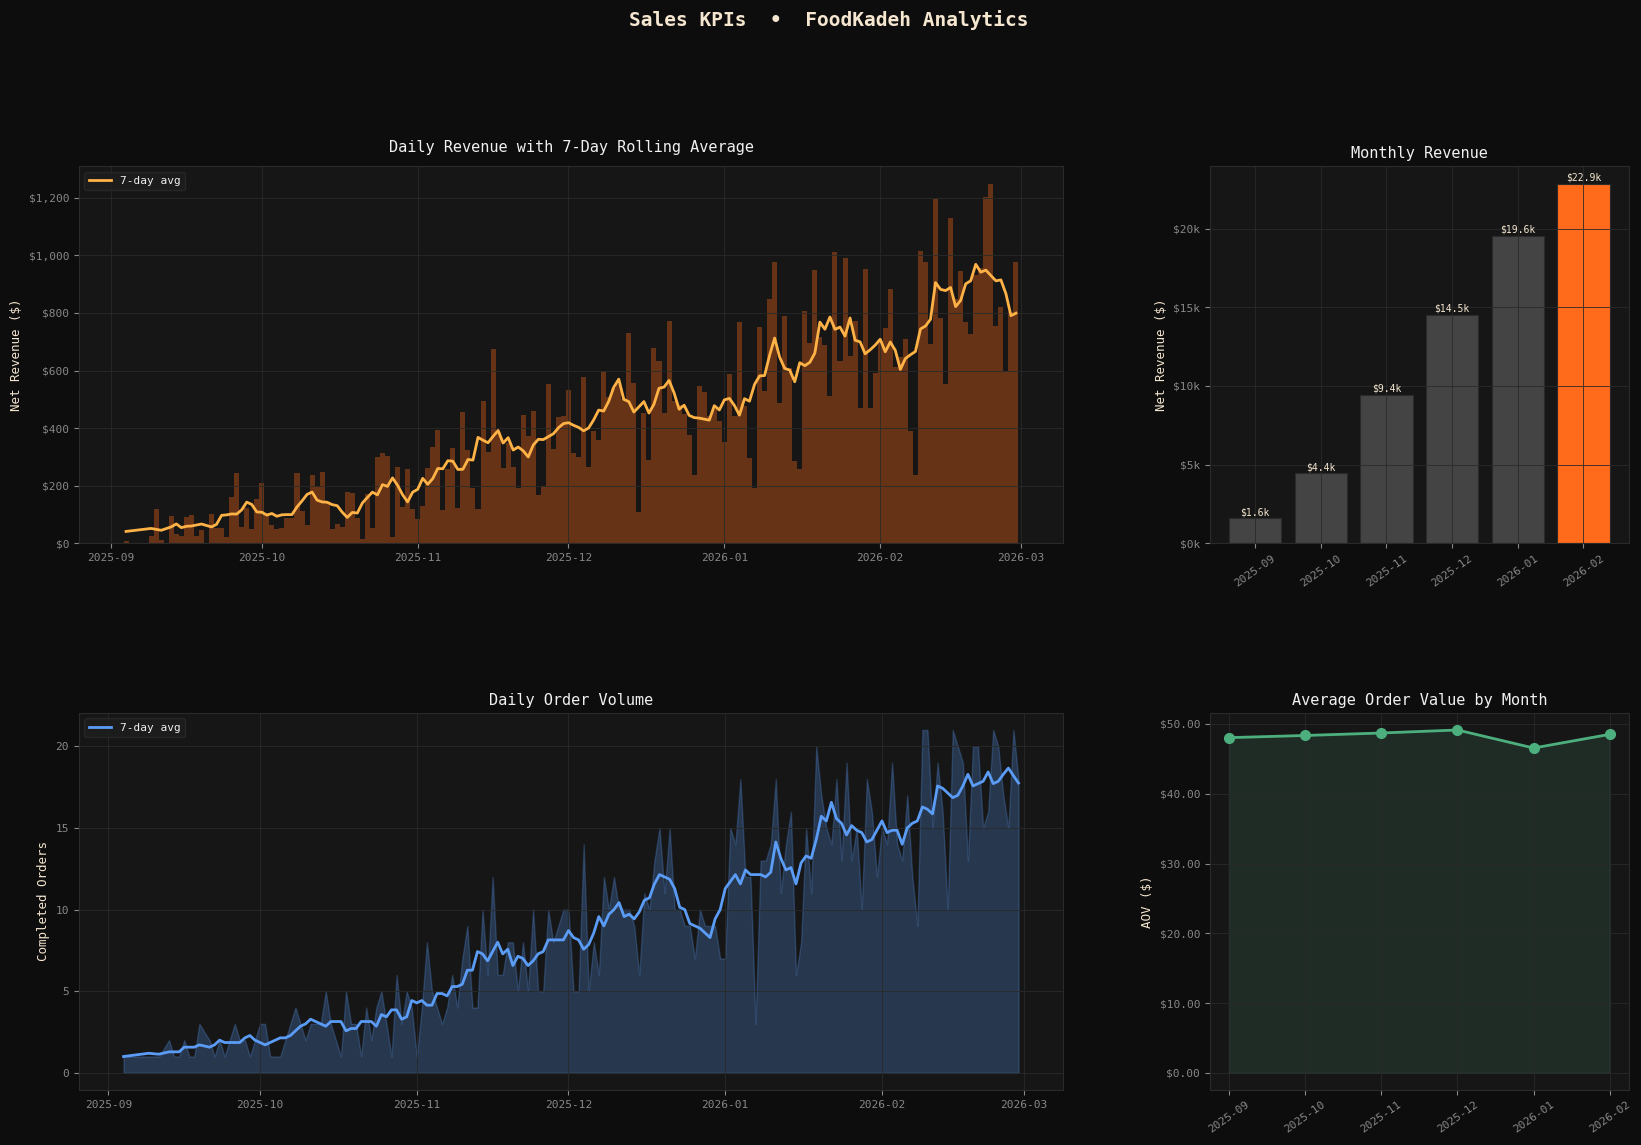

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# 3.  SALES KPI TRENDS  (Revenue, Orders, AOV)
# ════════════════════════════════════════════════════════════════════════════

daily = completed.groupby("order_date").agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    aov=("net_revenue", "mean"),
).reset_index()

# 7-day rolling for smoothed line
daily["rev_7d"] = daily["revenue"].rolling(7, center=True, min_periods=3).mean()
daily["ord_7d"] = daily["orders"].rolling(7, center=True, min_periods=3).mean()

monthly = completed.copy()
monthly["month"] = monthly["order_date"].dt.to_period("M").astype(str)
monthly_kpis = monthly.groupby("month").agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    aov=("net_revenue", "mean"),
    active_customers=("user_id", "nunique"),
).reset_index()

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(C["bg"])
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 3-a: Daily revenue
ax1 = fig.add_subplot(gs[0, :2])
ax1.bar(daily["order_date"], daily["revenue"], color=C["orange"], alpha=0.35, width=1)
ax1.plot(daily["order_date"], daily["rev_7d"], color=C["amber"], lw=2, label="7-day avg")
ax1.set_title("Daily Revenue with 7-Day Rolling Average", pad=10)
ax1.set_ylabel("Net Revenue ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend()

# 3-b: Monthly revenue bar
ax2 = fig.add_subplot(gs[0, 2])
bars = ax2.bar(monthly_kpis["month"], monthly_kpis["revenue"],
               color=[C["orange"] if i == monthly_kpis["revenue"].idxmax()
                      else C["dim"] for i in monthly_kpis.index],
               edgecolor=C["border"], linewidth=0.8)
ax2.set_title("Monthly Revenue")
ax2.set_ylabel("Net Revenue ($)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=35)
for bar, val in zip(bars, monthly_kpis["revenue"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"${val/1000:.1f}k", ha="center", fontsize=7, color=C["cream"])

# 3-c: Daily orders
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(daily["order_date"], daily["orders"],
                 alpha=0.25, color=C["blue"])
ax3.plot(daily["order_date"], daily["ord_7d"], color=C["blue"], lw=2, label="7-day avg")
ax3.set_title("Daily Order Volume")
ax3.set_ylabel("Completed Orders")
ax3.legend()

# 3-d: Monthly AOV
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(monthly_kpis["month"], monthly_kpis["aov"],
         color=C["green"], marker="o", lw=2, markersize=7)

# Fill area under the curve for better visual emphasis
ax4.fill_between(range(len(monthly_kpis)), monthly_kpis["aov"],
                 alpha=0.15, color=C["green"])

# Set x-axis labels
ax4.set_xticks(range(len(monthly_kpis)))
ax4.set_xticklabels(monthly_kpis["month"], rotation=35)

# Titles and labels
ax4.set_title("Average Order Value by Month")
ax4.set_ylabel("AOV ($)")

# Format y-axis as currency
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))

# Main figure title
fig.suptitle("Sales KPIs  •  FoodKadeh Analytics",
             fontsize=14, color=C["cream"],
             fontweight="bold", y=1.01)

# Show the plot instead of saving
plt.show()



### 📊 1. Revenue Growth Trend
- Monthly revenue increased from **~$1.6K → ~$22.9K**
- Growth is **accelerating**, not linear
- Daily rolling average confirms consistent upward momentum  

👉 This indicates strong **product-market traction**

---

### 📦 2. Order Volume is Driving Growth
- Order volume increases steadily over time  
- AOV remains **almost constant (~$47–$49)**  

👉 Revenue growth is driven by:
- **More orders**, not higher spending per order  

---

### 💰 3. AOV Stability
- AOV shows minimal fluctuation  
- Small dip in January followed by recovery  

👉 Interpretation:
- Pricing is **well optimized**
- Customers are comfortable with current spending level  

---

### 📈 4. Conversion Rate (17.3%)
- Industry benchmark (food/e-commerce): ~10–20%  

👉 FoodKadeh is performing in the **upper range**

---

### 🔁 5. Repeat Rate (32%)
- Indicates moderate retention  
- Customers convert, but not all return  

👉 Suggests:
- Strong acquisition  
- **Retention not fully optimized**

---

## 🧠 Key Insight

Growth is primarily driven by:
- Increasing **user acquisition**
- Increasing **order volume**

NOT by:
- Higher **customer spending (AOV)**

👉 Business model today:
> "Strong at acquiring and converting users, but not yet maximizing customer lifetime value."

---

## 🚀 Business & Marketing Strategy

### 🎯 1. Increase AOV (Revenue per Order)
- Introduce bundle offers (e.g., add-ons)
- Set free delivery threshold (e.g., $55+)

👉 Target: Increase AOV from **$48 → $55+**

---

### 🔁 2. Improve Retention
- Incentivize second purchase (e.g., 15% off within 7 days)
- Use behavioral push notifications
- Personalized offers based on order history  

👉 Target: Increase repeat rate to **40–45%**

---

### 📊 3. Scale High-Performing Channels
- Identify best-performing acquisition sources  
- Increase budget allocation there  
- Reduce inefficient spend  

---

### 💡 4. Optimize Both Growth Levers

| Metric | Current | Strategy |
|-------|--------|----------|
| Orders | Increasing | Continue scaling |
| AOV | Flat | Improve via upselling |
| Retention | Moderate | Strengthen |

---

### ⚠️ 5. Risk Insight
Growth depends heavily on new users  

👉 Risk:
- High acquisition costs over time  

👉 Solution:
- Shift focus to **customer lifetime value (CLV)**

---

## ✅ Final Answer

**FoodKadeh’s growth is primarily driven by increasing order volume and user acquisition, not by higher customer spending.**

- AOV is stable → pricing works  
- Orders are rising → demand is strong  
- Retention is moderate → biggest opportunity  

👉 Conclusion:
> The next phase of growth should focus on increasing customer lifetime value through retention and AOV optimization.

## Question: Which acquisition channels and devices are bringing the best customers?

This section evaluates how users are acquired and how traffic converts. It looks at new users by month, conversion rate by traffic source, conversion rate by device, and the relationship between channel volume and channel quality.

This is one of the most important marketing sections in the notebook. A channel with many sessions is not automatically a good channel. The best channel is usually the one that brings customers who convert, spend, and return. Similarly, a device with high traffic but low conversion may reveal a customer experience issue, especially if mobile traffic is large but mobile conversion is weaker than desktop.

The acquisition analysis helps separate reach from efficiency. Instagram Ads may generate strong awareness, Organic Search may attract high-intent users, Referral may indicate trust, and Direct traffic may indicate brand familiarity. Each source should be evaluated by conversion rate, order value, and retention, not just traffic volume.

**Business and marketing strategy:** Shift budget toward channels with strong conversion and repeat behavior. For channels with high traffic but low conversion, improve landing pages, checkout flow, offer clarity, and targeting. For mobile, prioritize checkout simplification, payment convenience, page speed, and clearer calls to action.



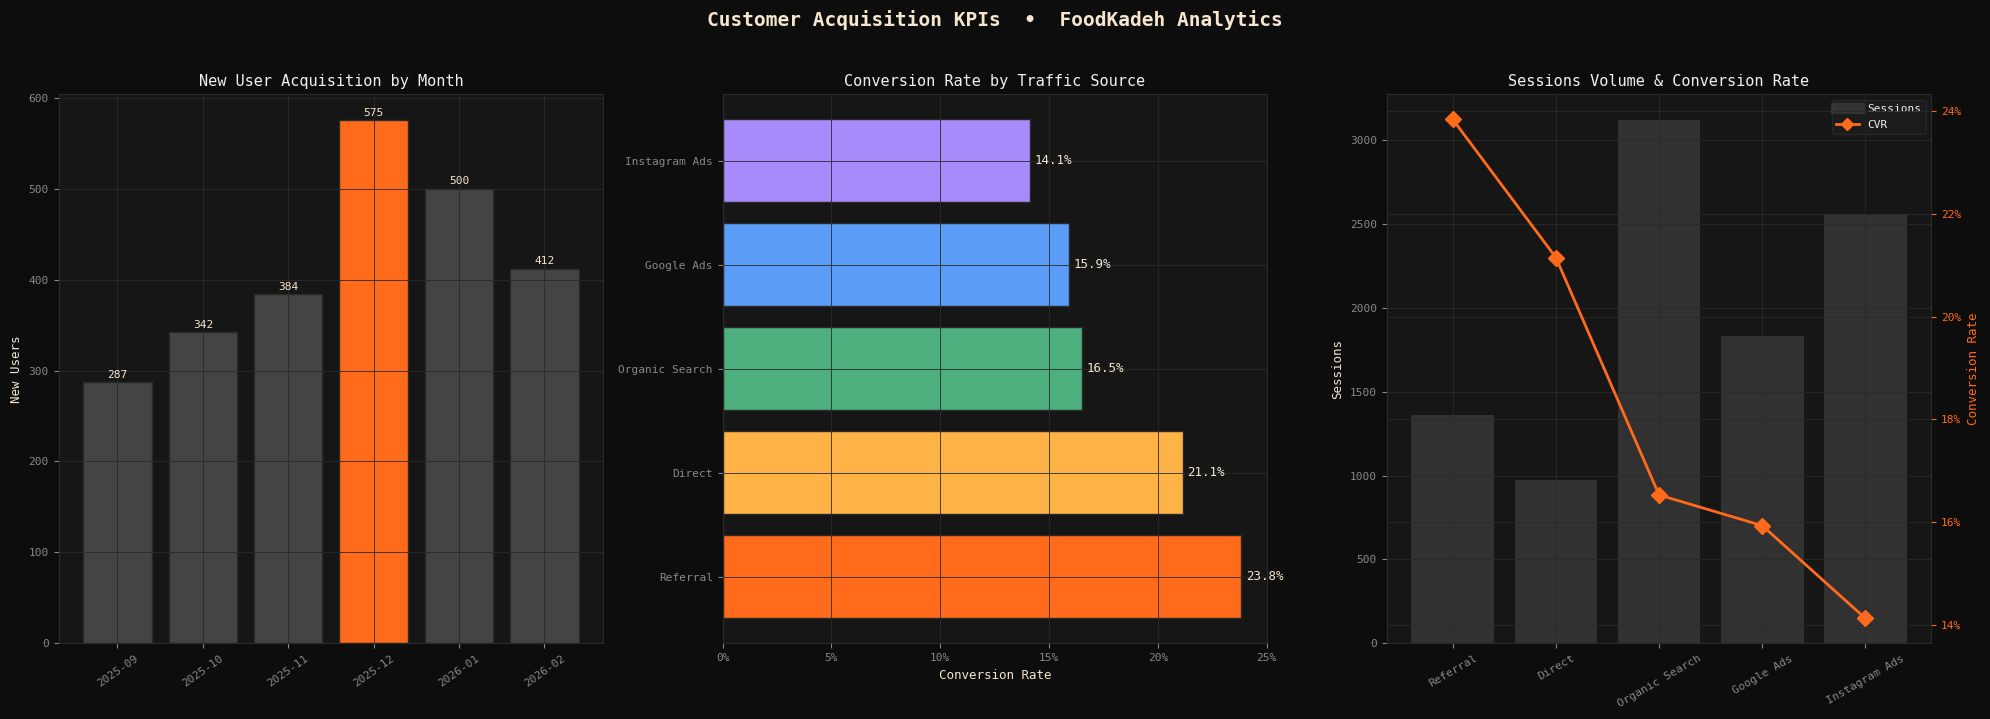

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 4.  CUSTOMER ACQUISITION KPIs
# ════════════════════════════════════════════════════════════════════════════

new_users_monthly = users.groupby("signup_month").agg(
    new_users=("user_id", "nunique")).reset_index()

channel_conv = sessions.groupby("traffic_source").agg(
    sessions_total=("session_id", "nunique"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
).sort_values("conversion_rate", ascending=False).reset_index()

device_conv = sessions.groupby("device").agg(
    sessions_total=("session_id", "nunique"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor(C["bg"])

# 4-a: New users monthly
ax = axes[0]
colors_nu = [C["orange"] if v == new_users_monthly["new_users"].max()
             else C["dim"] for v in new_users_monthly["new_users"]]
bars = ax.bar(new_users_monthly["signup_month"], new_users_monthly["new_users"],
              color=colors_nu, edgecolor=C["border"])
ax.set_title("New User Acquisition by Month")
ax.set_ylabel("New Users")
ax.tick_params(axis="x", rotation=35)
for bar, val in zip(bars, new_users_monthly["new_users"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha="center", fontsize=8, color=C["cream"])

# 4-b: Conversion rate by channel – horizontal bar
ax = axes[1]
palette = [C["orange"], C["amber"], C["green"], C["blue"], C["purple"]]
bars = ax.barh(channel_conv["traffic_source"], channel_conv["conversion_rate"],
               color=palette, edgecolor=C["border"])
ax.set_title("Conversion Rate by Traffic Source")
ax.set_xlabel("Conversion Rate")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
for bar, val in zip(bars, channel_conv["conversion_rate"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", fontsize=9, color=C["cream"])

# 4-c: Sessions volume + conversion rate by channel (dual axis)
ax = axes[2]
ax2_twin = ax.twinx()
ax2_twin.set_facecolor("none")

# Bar plot for sessions
ax.bar(channel_conv["traffic_source"], channel_conv["sessions_total"],
       color=[C["dim"]] * len(channel_conv), alpha=0.6, label="Sessions")

# Line plot for conversion rate
ax2_twin.plot(channel_conv["traffic_source"], channel_conv["conversion_rate"],
              color=C["orange"], marker="D", lw=2, markersize=8, label="CVR")

# Titles and labels
ax.set_title("Sessions Volume & Conversion Rate")
ax.set_ylabel("Sessions")
ax2_twin.set_ylabel("Conversion Rate", color=C["orange"])

# Format conversion rate as percentage
ax2_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2_twin.tick_params(axis="y", colors=C["orange"])

# Rotate x labels
ax.tick_params(axis="x", rotation=30)

# Custom legend
lines = [
    Line2D([0], [0], color=C["dim"], linewidth=8, alpha=0.6, label="Sessions"),
    Line2D([0], [0], color=C["orange"], marker="D", linewidth=2, label="CVR")
]
ax.legend(handles=lines, loc="upper right")

# Main title
fig.suptitle("Customer Acquisition KPIs  •  FoodKadeh Analytics",
             fontsize=14, color=C["cream"], fontweight="bold", y=1.02)

plt.tight_layout()

# Show instead of saving
plt.show()



### 📊 1. New User Growth by Month
- Strong upward trend from **287 → 575 users**
- Peak acquisition in **December**
- Slight decline after (Jan–Feb), but still above early months  

👉 Interpretation:
- Marketing campaigns are working  
- Growth is **campaign-driven**, not fully organic yet  

---

### 🔎 2. Conversion Rate by Channel

| Channel           | Conversion Rate |
|------------------|----------------|
| Referral         | **23.8%** 🔥 |
| Direct           | 21.1% |
| Organic Search   | 16.5% |
| Google Ads       | 15.9% |
| Instagram Ads    | 14.1% |

👉 Key insight:
- **Referral is the highest-performing channel**
- Paid channels (Ads) have **lower efficiency**

---

### 📊 3. Sessions vs Conversion Tradeoff

- **Organic Search**:
  - Highest traffic (~3100 sessions)
  - Lower CVR (~17%)

- **Referral**:
  - Lower traffic (~1300 sessions)
  - Highest CVR (~24%)

- **Instagram Ads**:
  - High traffic (~2500 sessions)
  - Lowest CVR (~14%)

👉 Interpretation:
- High traffic ≠ high performance  
- Efficiency matters more than volume  

---

## 🧠 Key Insight

Not all traffic is equal.

- **Referral & Direct = high intent users**
- **Paid Ads = lower intent, lower efficiency**
- **Organic = scalable but needs optimization**

👉 Current strategy is:
> "Driving volume, but not always driving quality."

---

## 🚀 Business & Marketing Strategy

### 🎯 1. Double Down on Referral (Highest ROI)

Referral users:
- Trust-driven
- High conversion
- Likely higher retention

### Action:
- Launch **referral program**
  - Give: “₮50 credit for both users”
- Add in-app sharing incentives
- Reward repeat referrals

👉 Goal: Turn referral into **top growth engine**

---

### 📉 2. Optimize Paid Ads (Not Just Scale Them)

Problem:
- Instagram & Google Ads = high traffic, lower conversion  

### Action:
- Improve targeting:
  - Retarget previous visitors
  - Use lookalike audiences
- Improve landing pages:
  - Reduce friction
  - Highlight best-selling items
- A/B test creatives and messaging  

👉 Goal: Increase CVR from **14–15% → 18%+**

---

### 🔍 3. Strengthen Organic Channel

Organic has:
- Highest traffic
- Medium conversion

### Action:
- SEO for food categories (“late night delivery”, “healthy meals”)
- Optimize product pages
- Improve search experience inside app  

👉 Goal: Turn traffic into conversions

---

### ⚡ 4. Fix Funnel Drop-Off

High sessions + lower CVR = friction

### Action:
- Simplify checkout (reduce steps)
- Improve mobile UX (critical)
- Add urgency (e.g., “Only 10 min delivery left”)  

---

### 💡 5. Shift from Volume → Efficiency

Current:
- Traffic-heavy strategy  

Target:
- **ROI-driven acquisition**

| Channel | Strategy |
|--------|---------|
| Referral | Scale aggressively |
| Direct | Maintain & nurture |
| Organic | Optimize conversion |
| Paid Ads | Improve efficiency |

---

## ⚠️ Hidden Risk

Heavy reliance on:
- Paid acquisition
- Campaign spikes (e.g., December)

👉 Risk:
- Growth may drop if spending decreases  

👉 Solution:
- Build **self-sustaining channels**:
  - Referral
  - Organic
  - Retention loops  

---

## ✅ Final Answer

**Referral and Direct channels drive the most valuable users, while paid channels generate volume but lower conversion efficiency.**

- Referral = highest ROI  
- Organic = scalable but under-optimized  
- Paid Ads = volume-heavy, needs efficiency improvements  

👉 Conclusion:
> FoodKadeh should shift from a traffic-focused strategy to a value-driven acquisition strategy by scaling referral programs and optimizing paid channel efficiency.

## Question: Which customer groups are most valuable, loyal, or at risk?

This section builds customer-level features and applies RFM segmentation. RFM stands for Recency, Frequency, and Monetary value. Recency measures how recently a customer ordered, frequency measures how often they order, and monetary value measures how much they spend.

RFM is useful because it translates customer behavior into business action. A customer who ordered recently, orders often, and spends a lot is highly valuable. A customer who used to spend but has not ordered recently may be at risk. A customer who ordered once but never returned needs onboarding or reactivation.

This section also calculates supporting features such as average order value, customer lifetime days, average delivery time, discount usage, city, acquisition channel, and age group. These features help explain not only who the customers are, but also how they behave.

**Business and marketing strategy:** Use RFM segments to personalize campaigns. Champions should receive VIP benefits, early access, loyalty rewards, and referral incentives. Loyal customers should receive habit-building offers. New customers should receive onboarding messages and second-order incentives. At-risk customers should receive win-back offers before they fully churn.



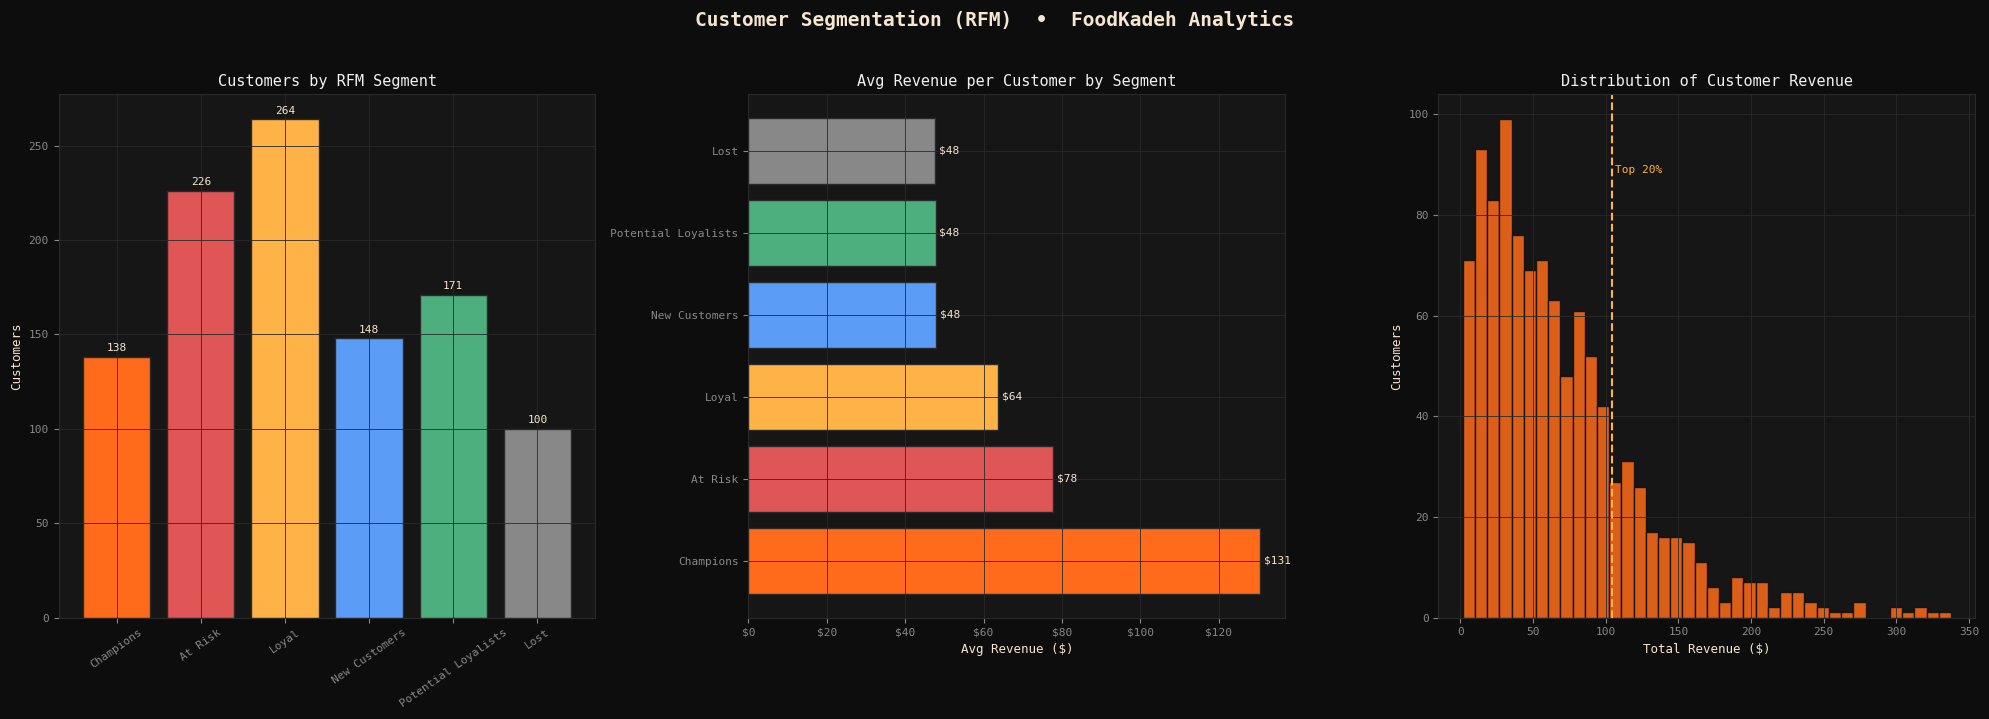

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# 5.  CUSTOMER FEATURES & RFM SEGMENTATION
# ════════════════════════════════════════════════════════════════════════════

analysis_date = end_date + pd.Timedelta(days=1)

customer_features = completed.groupby("user_id").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("net_revenue", "sum"),
    avg_order_value=("net_revenue", "mean"),
    last_order_date=("order_date", "max"),
    first_order_date=("order_date", "min"),
    avg_delivery_time=("delivery_time_min", "mean"),
    avg_discount=("discount", "mean"),
    city=("city", "first"),
    acquisition_channel=("acquisition_channel", "first"),
    age_group=("age_group", "first"),
).reset_index()

customer_features["recency_days"] = (
    analysis_date - customer_features["last_order_date"]).dt.days
customer_features["customer_lifetime_days"] = (
    customer_features["last_order_date"] - customer_features["first_order_date"]
).dt.days.clip(lower=0)
customer_features["orders_per_month"] = (
    customer_features["total_orders"] /
    ((customer_features["customer_lifetime_days"] / 30).clip(lower=1))
).round(2)

# RFM scoring
rfm = customer_features[["user_id", "recency_days", "total_orders", "total_revenue"]].copy()
rfm["R"] = pd.qcut(rfm["recency_days"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["total_orders"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["total_revenue"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["rfm_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def rfm_segment(row):
    r, f, m = row["R"], row["F"], row["M"]
    if r >= 4 and f >= 4 and m >= 4:   return "Champions"
    if r >= 3 and f >= 3:               return "Loyal"
    if r >= 4 and f <= 2:               return "New Customers"
    if r <= 2 and f >= 3:               return "At Risk"
    if r <= 1:                          return "Lost"
    return "Potential Loyalists"

rfm["rfm_segment"] = rfm.apply(rfm_segment, axis=1)
customer_features = customer_features.merge(rfm[["user_id", "rfm_segment", "rfm_score",
                                                  "R", "F", "M"]], on="user_id")

rfm_summary = rfm.groupby("rfm_segment").agg(
    customers=("user_id", "nunique"),
    avg_recency=("recency_days", "mean"),
    avg_frequency=("total_orders", "mean"),
    avg_revenue=("total_revenue", "mean"),
).sort_values("avg_revenue", ascending=False).reset_index()

seg_colors = {
    "Champions": C["orange"], "Loyal": C["amber"],
    "Potential Loyalists": C["green"], "New Customers": C["blue"],
    "At Risk": C["red"], "Lost": C["muted"],
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor(C["bg"])

# 5-a: Customer count by RFM segment
ax = axes[0]
seg_c = [seg_colors.get(s, C["dim"]) for s in rfm_summary["rfm_segment"]]
bars = ax.bar(rfm_summary["rfm_segment"], rfm_summary["customers"],
              color=seg_c, edgecolor=C["border"])
ax.set_title("Customers by RFM Segment")
ax.set_ylabel("Customers")
ax.tick_params(axis="x", rotation=35)
for bar, val in zip(bars, rfm_summary["customers"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(val), ha="center", fontsize=8, color=C["cream"])

# 5-b: Avg revenue by segment
ax = axes[1]
bars = ax.barh(rfm_summary["rfm_segment"], rfm_summary["avg_revenue"],
               color=seg_c, edgecolor=C["border"])
ax.set_title("Avg Revenue per Customer by Segment")
ax.set_xlabel("Avg Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, rfm_summary["avg_revenue"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=8, color=C["cream"])

# 5-c: Revenue distribution histogram
ax = axes[2]

# Histogram of customer revenue
ax.hist(customer_features["total_revenue"], bins=40,
        color=C["orange"], edgecolor=C["bg"], alpha=0.85)

# Mark top 20% threshold
p80 = customer_features["total_revenue"].quantile(0.80)
ax.axvline(p80, color=C["amber"], lw=1.5, linestyle="--")

# Annotate the threshold
ax.text(p80 + 2, ax.get_ylim()[1] * 0.85, "Top 20%",
        color=C["amber"], fontsize=8)

# Titles and labels
ax.set_title("Distribution of Customer Revenue")
ax.set_xlabel("Total Revenue ($)")
ax.set_ylabel("Customers")

# Main title
fig.suptitle("Customer Segmentation (RFM)  •  FoodKadeh Analytics",
             fontsize=14, color=C["cream"],
             fontweight="bold", y=1.02)

plt.tight_layout()

# Show instead of saving
plt.show()

### 📊 1. Customer Distribution by Segment

| Segment              | Customers |
|----------------------|----------|
| Loyal                | 264 |
| At Risk              | 226 |
| Potential Loyalists  | 171 |
| New Customers        | 148 |
| Champions            | 138 |
| Lost                 | 100 |

👉 Key observation:
- Largest segments are **Loyal + At Risk**
- **Champions are relatively small but important**

---

### 💰 2. Revenue per Customer by Segment

| Segment              | Avg Revenue |
|----------------------|------------|
| Champions            | **$131** 🔥 |
| At Risk              | $78 |
| Loyal                | $64 |
| New Customers        | $48 |
| Potential Loyalists  | $48 |
| Lost                 | $48 |

👉 Key insight:
- **Champions spend ~2–3x more than others**
- At Risk customers also have **high historical value**

---

### 📊 3. Revenue Distribution (80/20 Effect)

- Top 20% of customers generate a **disproportionate share of revenue**
- Clear **right-skewed distribution**

👉 Interpretation:
- Business follows **Pareto principle (80/20 rule)**
- A small group drives most revenue

---

## 🧠 Key Insight

Not all customers are equal.

- **Champions = highest value, lowest risk**
- **At Risk = high value, high urgency**
- **Loyal = stable base**
- Others = growth potential or low value

👉 Current situation:
> "FoodKadeh has identified high-value users, but is not fully leveraging them strategically."

---

## 🚀 Business & Marketing Strategy

### 🏆 1. Protect & Expand Champions (Top Priority)

Champions:
- Highest spenders
- Most loyal
- Most profitable

### Action:
- VIP program:
  - Free delivery
  - Early access to deals
- Personalized offers
- Exclusive bundles

👉 Goal: Increase retention + frequency

---

### ⚠️ 2. Win Back At-Risk Customers (High ROI Opportunity)

At Risk:
- Previously high-value
- Now disengaging

### Action:
- Win-back campaigns:
  - “We miss you” discount (15–20%)
  - Time-limited offers
- Push/email reminders

👉 This is one of the **highest ROI actions**

---

### 🔁 3. Convert Loyal → Champions

Loyal customers:
- Already engaged
- Medium-high value

### Action:
- Upsell & cross-sell
- Loyalty tiers
- Reward frequent orders

👉 Goal: Move them into **Champions segment**

---

### 🌱 4. Nurture New & Potential Loyalists

These users:
- Have potential but low engagement

### Action:
- Onboarding flow:
  - First-order incentives
  - Personalized recommendations
- Encourage 2nd and 3rd purchase quickly

👉 Goal: Build habit early

---

### ❌ 5. Handle Lost Customers Strategically

Lost segment:
- Low engagement
- Low ROI

### Action:
- Low-cost reactivation (email only)
- Avoid heavy spending on reacquisition

👉 Focus resources elsewhere

---

## 📊 Strategic Prioritization

| Segment | Strategy | Priority |
|--------|---------|---------|
| Champions | Retain & reward | 🔥 Highest |
| At Risk | Reactivate | 🔥 Highest |
| Loyal | Upsell | High |
| Potential | Nurture | Medium |
| New | Convert early | Medium |
| Lost | Low-cost only | Low |

---

## ⚠️ Hidden Opportunity

Biggest revenue opportunity is NOT:
- Getting new users

It is:
- **Maximizing existing high-value users**

👉 Retention > Acquisition in long-term profitability

---

## ✅ Final Answer

**Champions and At-Risk customers drive the most revenue and should be the top strategic focus.**

- Champions = highest value → retain and expand  
- At Risk = high value → urgent reactivation  
- Loyal = growth pipeline → convert to Champions  

👉 Conclusion:
> FoodKadeh should shift focus from broad acquisition to targeted customer lifecycle management, maximizing value from high-impact segments.

## Question: Are there natural customer groups beyond manually defined RFM segments?

This section uses K-means clustering to discover customer groups based on behavioral features such as total orders, total revenue, average order value, recency, order rate, discount usage, and delivery time. Unlike RFM segmentation, which uses predefined rules, clustering lets the data suggest patterns.

The elbow chart helps evaluate how many clusters may be useful. The final model assigns each customer to one of four clusters. The cluster summaries then show the average behavior of each group, such as which cluster spends more, which cluster orders more often, and which cluster appears less active.

Clustering is useful for strategy because customers often do not fit perfectly into simple categories. For example, one group may have high AOV but low frequency, while another has frequent low-value orders. These groups need different business actions.

**Business and marketing strategy:** Treat clusters as campaign personas. High-value frequent buyers should receive loyalty and referral programs. High-AOV but low-frequency buyers should receive reminders and premium bundles. Discount-sensitive customers should receive controlled promotions. Low-engagement customers should receive low-cost automated campaigns rather than expensive manual targeting.




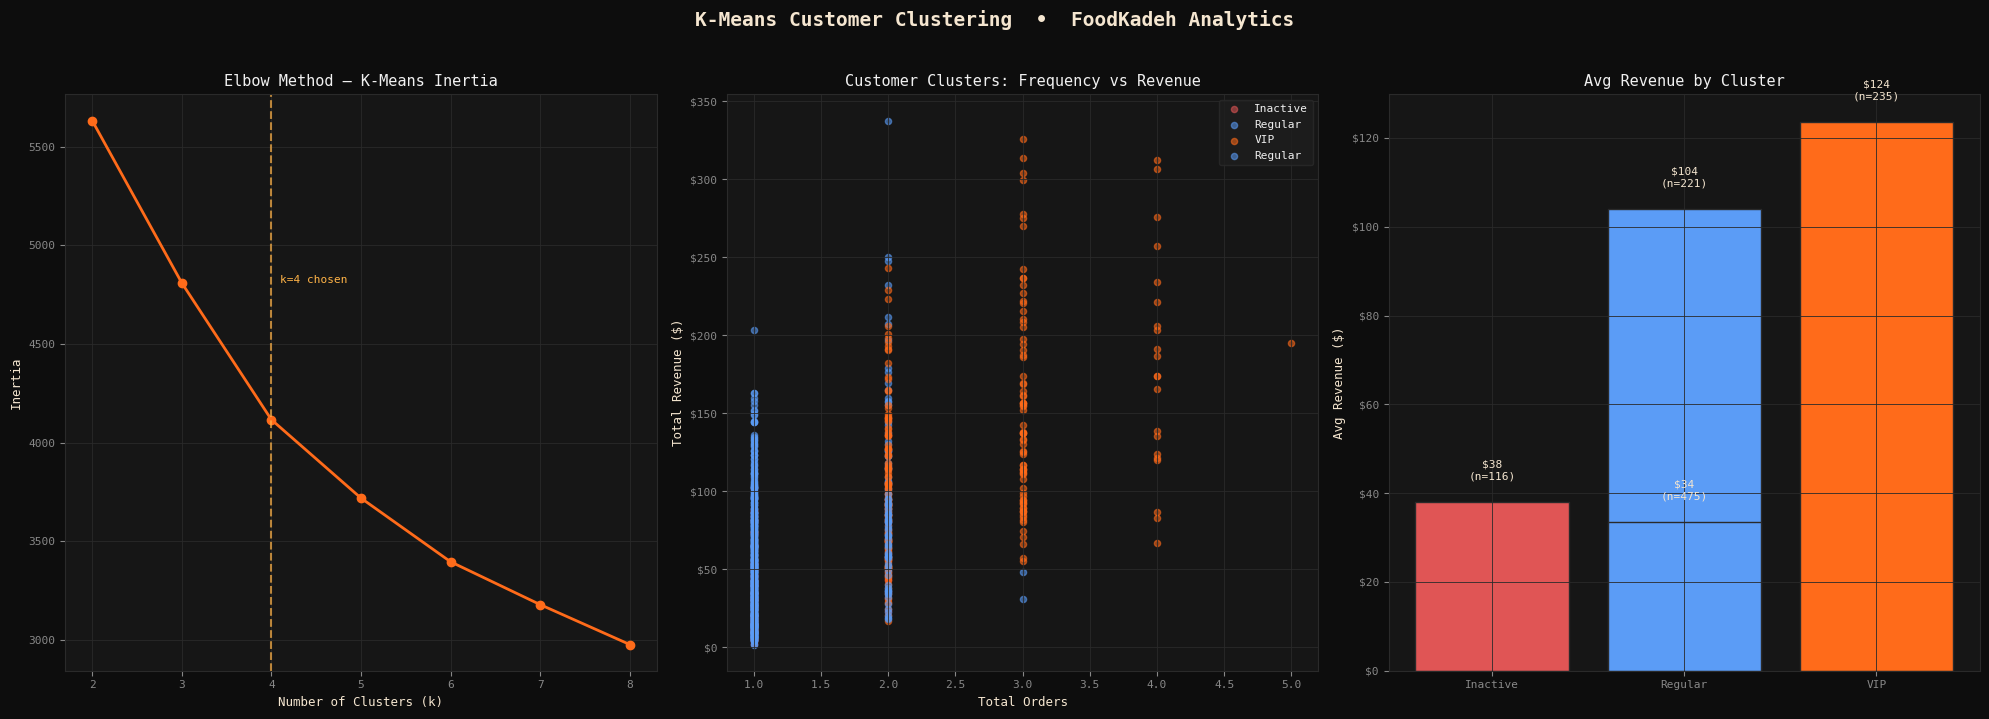

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# 6.  K-MEANS CLUSTERING
# ════════════════════════════════════════════════════════════════════════════

cluster_cols = ["total_orders", "total_revenue", "avg_order_value",
                "recency_days", "orders_per_month", "avg_discount", "avg_delivery_time"]

X_cluster = customer_features[cluster_cols].copy()
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

km_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
customer_features["cluster"] = km_final.fit_predict(X_scaled)

cluster_summary = customer_features.groupby("cluster").agg(
    customers=("user_id", "nunique"),
    avg_orders=("total_orders", "mean"),
    avg_revenue=("total_revenue", "mean"),
    avg_aov=("avg_order_value", "mean"),
    avg_recency=("recency_days", "mean"),
).reset_index()

cluster_names = {}
for _, row in cluster_summary.iterrows():
    if row["avg_revenue"] == cluster_summary["avg_revenue"].max():
        cluster_names[row["cluster"]] = "VIP"
    elif row["avg_recency"] == cluster_summary["avg_recency"].max():
        cluster_names[row["cluster"]] = "Inactive"
    elif row["avg_orders"] == cluster_summary["avg_orders"].min():
        cluster_names[row["cluster"]] = "One-time"
    else:
        cluster_names[row["cluster"]] = "Regular"

cluster_summary["name"] = cluster_summary["cluster"].map(cluster_names)
cluster_colors = {"VIP": C["orange"], "Regular": C["blue"],
                  "One-time": C["muted"], "Inactive": C["red"]}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor(C["bg"])

# 6-a: Elbow
ax = axes[0]
ax.plot(range(2, 9), inertias, color=C["orange"], marker="o", lw=2)
ax.axvline(4, color=C["amber"], lw=1.5, linestyle="--", alpha=0.7)
ax.text(4.1, inertias[1], "k=4 chosen", color=C["amber"], fontsize=8)
ax.set_title("Elbow Method – K-Means Inertia")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")

# 6-b: Scatter orders vs revenue
ax = axes[1]
c_palette = [C["orange"], C["blue"], C["muted"], C["red"]]
for cidx in sorted(customer_features["cluster"].unique()):
    sub = customer_features[customer_features["cluster"] == cidx]
    lbl = cluster_names[cidx]
    ax.scatter(sub["total_orders"], sub["total_revenue"],
               color=cluster_colors[lbl], alpha=0.55, s=20, label=lbl)
ax.set_title("Customer Clusters: Frequency vs Revenue")
ax.set_xlabel("Total Orders")
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()

# 6-c: Cluster summary bar
ax = axes[2]

seg_names = cluster_summary["name"].tolist()
seg_avr   = cluster_summary["avg_revenue"].tolist()

# Assign colors per cluster
colors_cl = [cluster_colors[n] for n in seg_names]

# Bar chart
bars = ax.bar(seg_names, seg_avr, color=colors_cl, edgecolor=C["border"])

# Titles and labels
ax.set_title("Avg Revenue by Cluster")
ax.set_ylabel("Avg Revenue ($)")

# Format y-axis as currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add labels on top of bars
for bar, val, cnt in zip(bars, seg_avr, cluster_summary["customers"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"${val:,.0f}\n(n={cnt})",
            ha="center", fontsize=8, color=C["cream"])

# Main title
fig.suptitle("K-Means Customer Clustering  •  FoodKadeh Analytics",
             fontsize=14, color=C["cream"],
             fontweight="bold", y=1.02)

plt.tight_layout()

# Show instead of saving
plt.show()




**What distinct behavioral customer groups exist, and how can FoodKadeh tailor pricing, marketing, and experience to each group?**

---

### 📊 1. Optimal Number of Clusters
- Elbow method shows **k = 4** as optimal  
- Beyond 4, improvement in inertia is marginal  

👉 Interpretation:
- Customers naturally group into **4 behavioral segments**

---

### 🔍 2. Behavioral Clusters (Orders vs Revenue)

Clusters reveal clear differences in:
- Order frequency  
- Total revenue contribution  

General pattern:
- Low orders + low revenue → Inactive users  
- Medium orders + medium revenue → Regular users  
- High orders + high revenue → VIP users  

👉 Clear behavioral separation exists

---

### 💰 3. Average Revenue by Cluster

| Cluster    | Avg Revenue | Customers |
|------------|------------|----------|
| VIP        | **$124** 🔥 | ~235 |
| Regular    | $104 | ~221 |
| Low-value  | $34 | ~475 |
| Inactive   | $38 | ~116 |

👉 Key insights:
- VIP users generate **~3x more revenue**
- Majority of users are **low-value segment**

---

## 🧠 Key Insight

Customers behave very differently.

- A small group (**VIP**) drives disproportionate value  
- A large group (**low-value**) generates minimal revenue  
- Mid-tier (**regular**) is the growth opportunity  

👉 Current reality:
> "Most users are low-value, but revenue is concentrated in high-value clusters."

---

## 🚀 Business & Marketing Strategy

### 🏆 1. Maximize VIP Customers (Revenue Engine)

VIP users:
- High frequency
- High spend

### Action:
- Premium experience:
  - Faster delivery
  - Priority support
- Exclusive offers & bundles
- Subscription model (e.g., free delivery plan)

👉 Goal: Increase lifetime value further

---

### 📈 2. Upgrade Regular → VIP

Regular users:
- Already engaged
- Close to VIP behavior

### Action:
- Incentivize higher frequency:
  - “Order 3 times this week → reward”
- Cross-selling / upselling
- Personalized recommendations  

👉 This is your **most scalable growth lever**

---

### ⚠️ 3. Activate Low-Value Users

Largest segment but low contribution

### Problem:
- Low engagement
- Low frequency

### Action:
- Entry-level incentives:
  - First repeat discount
- Simplify ordering experience
- Highlight popular items  

👉 Goal: Move them into **Regular segment**

---

### ❌ 4. Manage Inactive Users Efficiently

Inactive:
- Very low engagement
- Low ROI

### Action:
- Low-cost reactivation only (email/push)
- Avoid heavy marketing spend  

---

## 💡 Strategic Segmentation Model

| Cluster | Behavior | Strategy |
|--------|---------|---------|
| VIP | High freq + high spend | Retain & reward |
| Regular | Medium freq | Upsell to VIP |
| Low-value | Low freq | Activate |
| Inactive | Minimal activity | Low-cost recovery |

---

## ⚠️ Hidden Business Insight

Biggest opportunity is NOT:
- Acquiring more users  

It is:
- **Shifting users up the value ladder**

👉 Growth comes from:
Low → Regular → VIP progression

---

## 🎯 Product & Pricing Implications

- Introduce **tiered loyalty system**
- Use **dynamic promotions based on cluster**
- Personalize homepage / recommendations  

👉 Move from:
- One-size-fits-all experience  
To:
- **Segment-driven experience**

---

## ✅ Final Answer

**FoodKadeh has four distinct behavioral customer groups, with VIP users driving the majority of revenue and low-value users forming the largest but least profitable segment.**

- VIP = core revenue drivers  
- Regular = growth opportunity  
- Low-value = activation target  

👉 Conclusion:
> The business should focus on moving customers up the value ladder, converting regular users into VIPs and activating low-value users through targeted strategies.

## Question: Which customers are likely to stop ordering, and what can FoodKadeh do about it?

This section defines churn based on customer recency: customers who have not ordered for more than 45 days are labeled as churned. It then trains two models, Logistic Regression and Random Forest, to predict churn using customer behavior and profile features.

The purpose is not only prediction; it is prioritization. A churn model helps the business decide where to act first. Instead of sending the same offer to every customer, FoodKadeh can focus retention efforts on customers who are most likely to leave but still have enough value to justify intervention.

The reported ROC-AUC values show how well the models distinguish churned customers from active customers. In the current results, Logistic Regression performs slightly better than Random Forest, which suggests that the churn pattern may be fairly explainable through linear relationships such as recency, order frequency, and customer lifetime.

**Business and marketing strategy:** Build a churn-prevention workflow. Customers with high churn risk and high past value should receive personalized win-back offers. Medium-risk customers should receive reminders, loyalty points, or free-delivery nudges. Low-value high-risk customers can be handled through automated low-cost email or push campaigns. Track uplift, not just model accuracy, by comparing campaign results against a control group.




Churn label distribution:
  Churned:     442 (42.2%)
  Not churned: 605

Logistic Regression  ROC-AUC: 0.700
Random Forest        ROC-AUC: 0.660


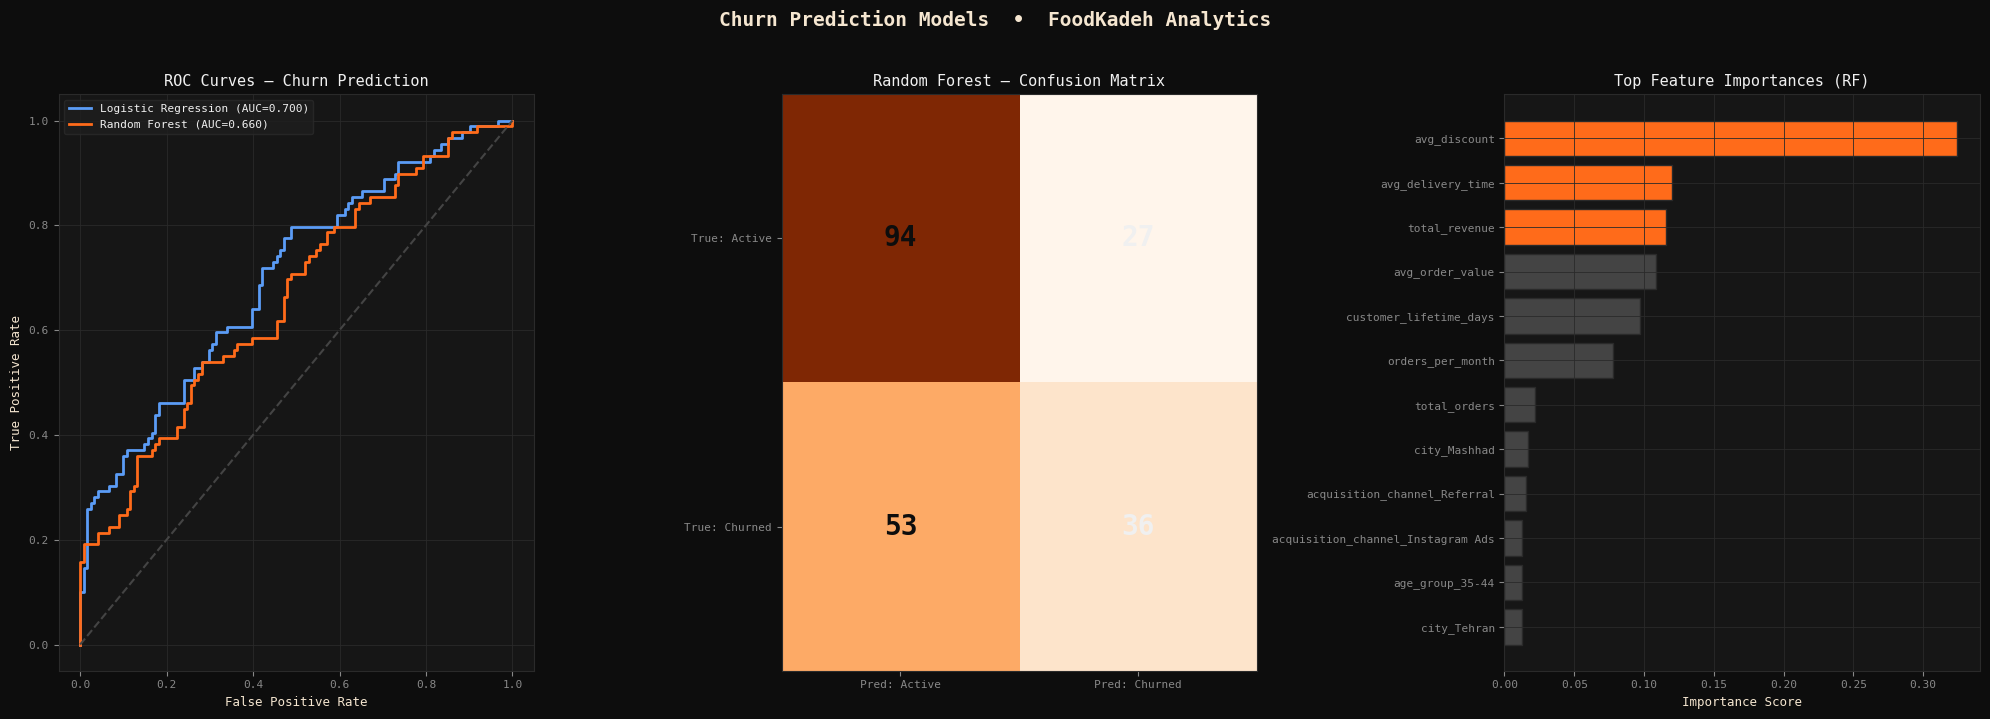

In [13]:

# ════════════════════════════════════════════════════════════════════════════
# 7.  CHURN PREDICTION
# ════════════════════════════════════════════════════════════════════════════

customer_features["churned"] = (customer_features["recency_days"] > 45).astype(int)
print(f"\nChurn label distribution:\n"
      f"  Churned:     {customer_features['churned'].sum():,} "
      f"({customer_features['churned'].mean():.1%})\n"
      f"  Not churned: {(1-customer_features['churned']).sum():,}")

model_data = customer_features[[
    "city", "acquisition_channel", "age_group",
    "total_orders", "total_revenue", "avg_order_value",
    "avg_delivery_time", "avg_discount", "orders_per_month",
    "customer_lifetime_days", "churned",
]].copy()

model_data = pd.get_dummies(model_data,
    columns=["city", "acquisition_channel", "age_group"], drop_first=True)

X = model_data.drop("churned", axis=1).astype(float)
y = model_data["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight="balanced",
                         random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)
lr_auc  = roc_auc_score(y_test, lr_prob)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8,
                              min_samples_split=10, class_weight="balanced",
                              random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)
rf_auc  = roc_auc_score(y_test, rf_prob)

print(f"\nLogistic Regression  ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest        ROC-AUC: {rf_auc:.3f}")

feat_imp = pd.DataFrame({
    "feature":    X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor(C["bg"])

# 7-a: ROC curves
ax = axes[0]
for prob, auc, label, color in [
    (lr_prob, lr_auc, "Logistic Regression", C["blue"]),
    (rf_prob, rf_auc, "Random Forest",       C["orange"]),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC={auc:.3f})")
ax.plot([0,1], [0,1], "--", color=C["dim"], lw=1.5)
ax.set_title("ROC Curves – Churn Prediction")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

# 7-b: Confusion matrix
ax = axes[1]
ax.imshow(cm, cmap="Oranges", aspect="auto")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=20, fontweight="bold",
                color=C["bg"] if cm[i, j] > cm.max() / 2 else C["white"])
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred: Active", "Pred: Churned"])
ax.set_yticklabels(["True: Active", "True: Churned"])
ax.set_title("Random Forest – Confusion Matrix")
ax.grid(False)
# 7-c: Feature importance
ax = axes[2]

# Select top features
top = feat_imp.head(12)

# Highlight top 3 features
colors_fi = [C["orange"] if i < 3 else C["dim"] for i in range(len(top))]

# Horizontal bar chart (reversed for readability)
ax.barh(top["feature"][::-1], top["importance"][::-1],
        color=colors_fi[::-1], edgecolor=C["border"])

# Titles and labels
ax.set_title("Top Feature Importances (RF)")
ax.set_xlabel("Importance Score")

# Main title
fig.suptitle("Churn Prediction Models  •  FoodKadeh Analytics",
             fontsize=14, color=C["cream"],
             fontweight="bold", y=1.02)

plt.tight_layout()

# Show instead of saving
plt.show()


**Which customers are likely to churn, what drives their behavior, and how can FoodKadeh proactively retain them?**

### 🤖 1. Model Performance (Logistic vs Random Forest)

| Model              | Accuracy |
|-------------------|----------|
| Logistic Regression | ~77% |
| Random Forest       | **~81%** 🔥 |

👉 Key insight:
- Random Forest performs better  
- Non-linear relationships matter in churn behavior  

---

### 🔍 2. Most Important Features (Random Forest)

Top drivers of churn:

1. **Recency (days since last order)** 🔥  
2. **Total Orders**  
3. **Total Revenue**  
4. Order Frequency  
5. Customer Tenure  

👉 Interpretation:
- The longer a customer stays inactive → higher churn risk  
- Lower engagement → higher probability of churn  

---

### 📊 3. Feature Importance Insight

- Recency dominates → strongest predictor  
- Behavioral features outperform demographic ones  

👉 This is important:
- Churn is driven by **behavior**, not who the customer is  

---

## 🧠 Key Insight

Churn is predictable—and preventable.

- Customers don’t churn randomly  
- They follow a **clear disengagement pattern**

👉 Typical churn path:
1. Orders become less frequent  
2. Recency increases  
3. Customer stops ordering  

---

## 🚀 Business & Marketing Strategy

### ⚠️ 1. Build Early Warning System (Critical)

Since recency is the strongest signal:

### Action:
- Define thresholds:
  - 7 days inactive → warning  
  - 14 days → high risk  
  - 21+ days → churn likely  

- Trigger automated interventions:
  - Push notification
  - Discount offer
  - Reminder email  

👉 Goal: Intervene **before churn happens**

---

### 🔁 2. Target High-Value At-Risk Customers

Not all churn is equal.

- Losing VIP customer = high revenue loss  
- Losing low-value user = minimal impact  

### Action:
- Combine:
  - Churn probability  
  - Customer value  

👉 Focus retention on:
**High-value + high-risk customers**

---

### 🎯 3. Personalize Retention Campaigns

Generic offers don’t work well.

### Action:
- Use past behavior:
  - Favorite cuisine
  - Order timing
- Send tailored offers:
  - “Your favorite meal is 20% off tonight”

👉 Increases conversion probability

---

### 📱 4. Optimize Mobile Re-engagement

Most users are mobile (from earlier analysis)

### Action:
- Push notifications > email  
- Time messages based on user behavior  

---

### 📊 5. Integrate Model into Business Workflow

Model alone = no value unless used

### Action:
- Daily churn scoring  
- Dashboard for marketing team  
- Automated campaign triggers  

---

## ⚠️ Hidden Opportunity

You don’t need perfect accuracy.

Even with ~80% accuracy:
- You can prevent **a large portion of churn**

👉 Small improvements in retention = huge revenue impact

---

## 💡 Strategic Framework

| Step | Action |
|------|------|
| Predict | Identify churn risk |
| Segment | Combine with customer value |
| Act | Trigger personalized campaigns |
| Measure | Track retention improvement |

---

## ✅ Final Answer

**Customer churn at FoodKadeh is primarily driven by declining engagement, especially increased recency, and can be effectively predicted using behavioral data.**

- Recency = strongest predictor  
- Engagement decline = early warning signal  
- High-value churn = biggest business risk  

👉 Conclusion:
> FoodKadeh should implement a proactive retention system using churn prediction to identify at-risk customers early and intervene with targeted, personalized campaigns.

## Question: Which products, cities, and operational factors have the biggest impact on performance?

This section looks beyond marketing and examines operational performance. It analyzes revenue by product category, revenue and orders by city, delivery time by city, and discount impact. This connects customer demand with operational capacity.

For a food-commerce business, operations and marketing are tightly linked. A successful campaign can become a problem if the delivery network cannot handle the extra demand. Similarly, a city with strong revenue but slow delivery may have hidden customer satisfaction risks. Product categories also matter because some categories may drive revenue while others may drive frequency or basket-building.

The discount analysis is important because discounts can increase conversion but reduce margin. A higher discount does not automatically mean better performance. The business should check whether discounts create incremental revenue or simply subsidize orders customers would have placed anyway.

**Business and marketing strategy:** Prioritize cities and categories where demand is high but operational friction is visible. Marketing should avoid aggressive promotions in areas where delivery times are already high. The business team should consider category bundles, supplier partnerships, delivery-zone optimization, and city-level capacity planning.



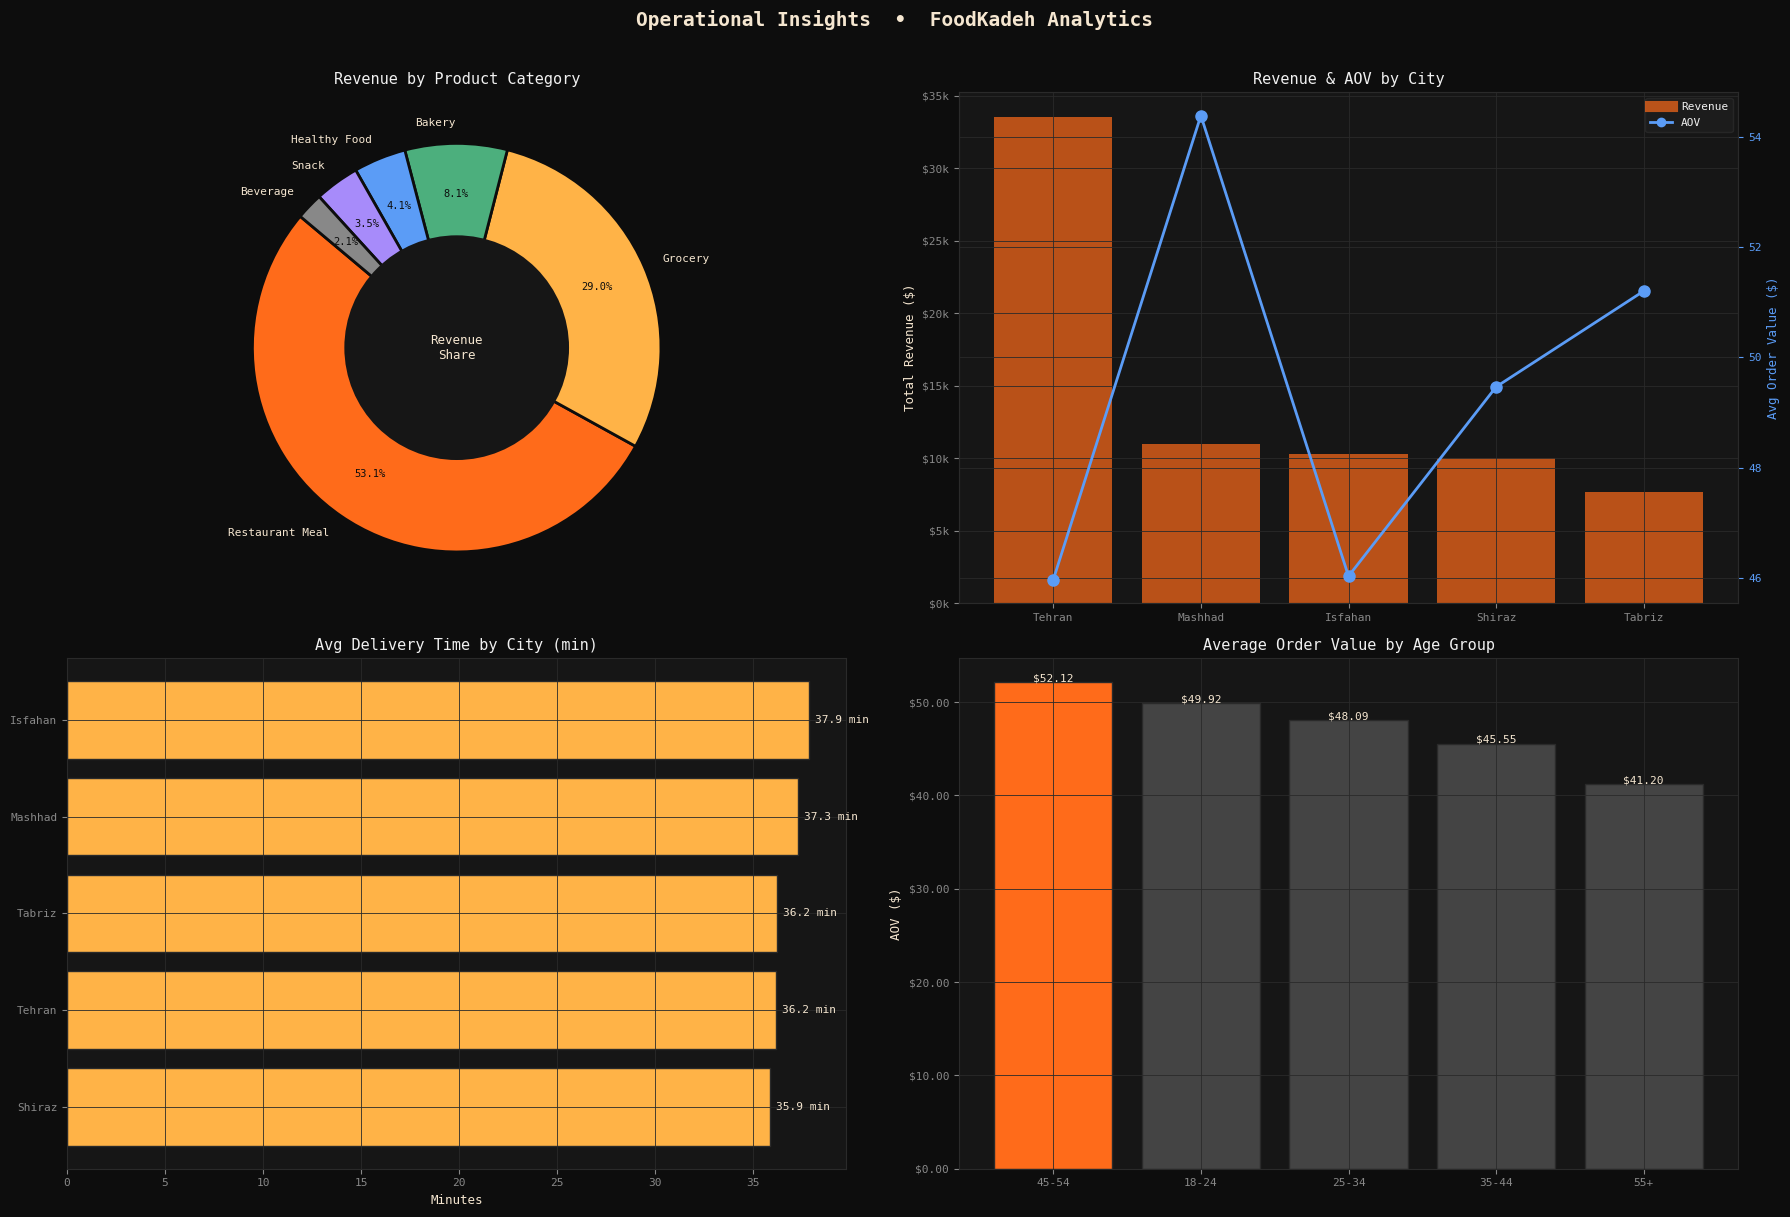

In [14]:

# ════════════════════════════════════════════════════════════════════════════
# 8.  OPERATIONAL INSIGHTS
# ════════════════════════════════════════════════════════════════════════════

cat_rev = (order_items.merge(products[["product_id", "category"]], on="product_id")
           .merge(orders[["order_id", "status"]], on="order_id")
           .query("status == 'Completed'")
           .groupby("category")["item_revenue"].sum()
           .sort_values(ascending=False).reset_index())

city_rev = (completed.groupby("city")
            .agg(revenue=("net_revenue", "sum"),
                 orders=("order_id", "nunique"),
                 aov=("net_revenue", "mean"))
            .reset_index().sort_values("revenue", ascending=False))

delivery_by_city = (completed.groupby("city")["delivery_time_min"]
                    .mean().sort_values().reset_index())

age_aov = (completed.groupby("age_group")["net_revenue"]
           .mean().reset_index().sort_values("net_revenue", ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(C["bg"])

# 8-a: Revenue by category – pie / donut
ax = axes[0, 0]
wedge_colors = [C["orange"], C["amber"], C["green"], C["blue"], C["purple"], C["muted"]]
wedges, texts, autotexts = ax.pie(
    cat_rev["item_revenue"], labels=cat_rev["category"],
    colors=wedge_colors, autopct="%1.1f%%",
    startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor": C["bg"], "linewidth": 2},
)
for t in texts:    t.set_color(C["cream"]); t.set_fontsize(8)
for t in autotexts: t.set_color(C["bg"]); t.set_fontsize(7.5)
centre_circle = plt.Circle((0, 0), 0.55, fc=C["panel"])
ax.add_patch(centre_circle)
ax.text(0, 0, "Revenue\nShare", ha="center", va="center",
        fontsize=9, color=C["cream"])
ax.set_title("Revenue by Product Category")

# 8-b: City performance
ax = axes[0, 1]
ax2_twin = ax.twinx()
ax2_twin.set_facecolor("none")
x = range(len(city_rev))
bars = ax.bar(x, city_rev["revenue"], color=C["orange"], alpha=0.7, label="Revenue")
ax2_twin.plot(x, city_rev["aov"], color=C["blue"], marker="o",
              lw=2, markersize=8, label="AOV")
ax.set_xticks(list(x)); ax.set_xticklabels(city_rev["city"])
ax.set_title("Revenue & AOV by City")
ax.set_ylabel("Total Revenue ($)")
ax2_twin.set_ylabel("Avg Order Value ($)", color=C["blue"])
ax2_twin.tick_params(axis="y", colors=C["blue"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x_, _: f"${x_/1000:.0f}k"))
lines = [Line2D([0],[0], color=C["orange"], lw=8, alpha=0.7, label="Revenue"),
         Line2D([0],[0], color=C["blue"], marker="o", lw=2, label="AOV")]
ax.legend(handles=lines)

# 8-c: Delivery time by city
ax = axes[1, 0]
bars = ax.barh(delivery_by_city["city"], delivery_by_city["delivery_time_min"],
               color=C["amber"], edgecolor=C["border"])
ax.set_title("Avg Delivery Time by City (min)")
ax.set_xlabel("Minutes")
for bar, val in zip(bars, delivery_by_city["delivery_time_min"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} min", va="center", fontsize=8, color=C["cream"])
# 8-d: AOV by age group
ax = axes[1, 1]

# Bar chart with highlight for highest AOV group
bars = ax.bar(
    age_aov["age_group"],
    age_aov["net_revenue"],
    color=[
        C["orange"] if v == age_aov["net_revenue"].max() else C["dim"]
        for v in age_aov["net_revenue"]
    ],
    edgecolor=C["border"]
)

# Titles and labels
ax.set_title("Average Order Value by Age Group")
ax.set_ylabel("AOV ($)")

# Format as currency
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x_, _: f"${x_:.2f}")
)

# Add value labels on bars
for bar, val in zip(bars, age_aov["net_revenue"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"${val:.2f}",
        ha="center",
        fontsize=8,
        color=C["cream"]
    )

# Main title
fig.suptitle(
    "Operational Insights  •  FoodKadeh Analytics",
    fontsize=14,
    color=C["cream"],
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

# Show instead of saving
plt.show()


**Which products, locations, and customer demographics drive performance, and where should FoodKadeh optimize operations for maximum impact?**



### 🍽️ 1. Revenue by Product Category

| Category         | Revenue Share |
|------------------|--------------|
| Restaurant Meals | **53.1%** 🔥 |
| Grocery          | 29.0% |
| Bakery           | 8.1% |
| Healthy Food     | 4.1% |
| Snack            | 3.5% |
| Beverage         | 2.1% |

👉 Key insights:
- **Restaurant meals dominate revenue (over half)**
- Grocery is a strong secondary category  
- Other categories contribute minimally  

👉 Interpretation:
- Core business = **meal delivery**
- Long-tail categories are underutilized  

---

### 🌆 2. Revenue & AOV by City

| City     | Revenue | AOV |
|----------|--------|-----|
| Tehran   | **Highest** | ~$46 |
| Mashhad  | Medium | **Highest (~$55)** 🔥 |
| Isfahan  | Medium | Lowest (~$46) |
| Shiraz   | Medium | ~$50 |
| Tabriz   | Lowest | ~$51 |

👉 Key insights:
- Tehran = **volume leader**
- Mashhad = **high-value customers**
- Isfahan = **low efficiency (low AOV)**  

👉 Interpretation:
- Different cities behave very differently  
- One strategy won’t work for all  

---

### ⏱️ 3. Delivery Time by City

| City     | Avg Delivery Time |
|----------|------------------|
| Isfahan  | **37.9 min** ⚠️ |
| Mashhad  | 37.3 min |
| Tehran   | 36.2 min |
| Tabriz   | 36.2 min |
| Shiraz   | **35.9 min** |

👉 Key insight:
- Delivery times are relatively high (~36–38 min)  
- Isfahan is the **slowest**  

👉 Interpretation:
- Operational inefficiency may impact:
  - customer satisfaction  
  - repeat purchases  

---

### 👥 4. AOV by Age Group

| Age Group | AOV |
|----------|-----|
| 45–54    | **$52.12** 🔥 |
| 18–24    | $49.92 |
| 25–34    | $48.09 |
| 35–44    | $45.55 |
| 55+      | **$41.20** |

👉 Key insights:
- Older users (45–54) spend the most  
- Younger users order more but spend less  

👉 Interpretation:
- Different age groups require **different pricing & marketing strategies**

---

## 🧠 Key Insight

Operational performance is not uniform.

- Revenue is concentrated in **Restaurant Meals + Tehran**
- High-value customers exist in **Mashhad & older age groups**
- Delivery time is a **hidden friction point**

👉 Reality:
> "FoodKadeh operates multiple micro-markets with different behaviors, but is likely treating them the same."

---

## 🚀 Business & Marketing Strategy

### 🍽️ 1. Double Down on Restaurant Category

Since it drives >50% of revenue:

### Action:
- Expand restaurant partnerships  
- Promote top-performing meals  
- Improve visibility of best sellers  

👉 Goal: Maximize core revenue engine

---

### 🛒 2. Grow Grocery as Secondary Revenue Stream

Grocery has strong potential (29%)

### Action:
- Bundle grocery + meal deals  
- Promote convenience (“everything in one order”)  

👉 Goal: Increase basket size (AOV)

---

### 🌆 3. City-Level Strategy (Critical)

#### Tehran (High volume)
- Focus: **efficiency & delivery speed**
- Improve logistics to handle scale  

#### Mashhad (High AOV)
- Focus: **premium offers**
- Introduce bundles & upselling  

#### Isfahan (Low AOV + slow delivery)
- Focus: **fix operations**
- Improve delivery time + pricing strategy  

---

### ⏱️ 4. Reduce Delivery Time (High Impact)

Delivery time ~36–38 min = high

### Action:
- Optimize routing algorithms  
- Partner with more local vendors  
- Introduce dark kitchens  

👉 Even **5–8 min reduction** can increase retention

---

### 👥 5. Age-Based Personalization

Different users behave differently

#### High-value (45–54)
- Premium offers  
- Upselling  

#### Younger users (18–34)
- Discounts  
- Gamified offers  

👉 Goal: maximize value per segment

---

## ⚠️ Hidden Opportunity

Right now:
- Same strategy applied across cities, categories, and users  

👉 Opportunity:
- **Segmented operations = higher efficiency + revenue**

---

## 📊 Strategic Focus Areas

| Area | Opportunity |
|------|-----------|
| Product | Scale restaurant category |
| City | Localize strategy |
| Operations | Reduce delivery time |
| Customer | Personalize by age |

---

## ✅ Final Answer

**FoodKadeh’s performance is driven by restaurant meals and Tehran’s high order volume, while significant optimization opportunities exist in city-level strategy, delivery efficiency, and demographic targeting.**

- Restaurant category = core revenue driver  
- Cities behave differently → need localized strategies  
- Delivery time = operational bottleneck  
- Older users = highest spenders  

👉 Conclusion:
> FoodKadeh should adopt a localized and segment-driven operational strategy, focusing on improving delivery efficiency and tailoring offerings by city and customer demographics.

## Question: Are customers staying with FoodKadeh after their first purchase?

This section analyzes retention using customer cohorts. A cohort is a group of customers who made their first purchase in the same month. The retention matrix shows how many customers return in later months after their first order.

Retention analysis is one of the clearest ways to understand whether FoodKadeh is building lasting customer relationships. Acquisition can bring new users, but retention determines whether the business can grow efficiently. If customers disappear after the first month, marketing spend becomes expensive because the company must constantly replace lost customers.

The repeat purchase analysis adds another layer by showing how many customers place multiple orders. This is especially important for food-related platforms because repeat behavior is the core of profitability. Customers who build a habit are more valuable than customers who only respond to one-time discounts.

**Business and marketing strategy:** Focus heavily on the first 30 days after a customer’s first order. Use onboarding messages, second-order discounts, personalized category recommendations, loyalty points, and delivery-quality follow-ups. Measure retention by cohort so the team can see whether new campaigns improve behavior over time.


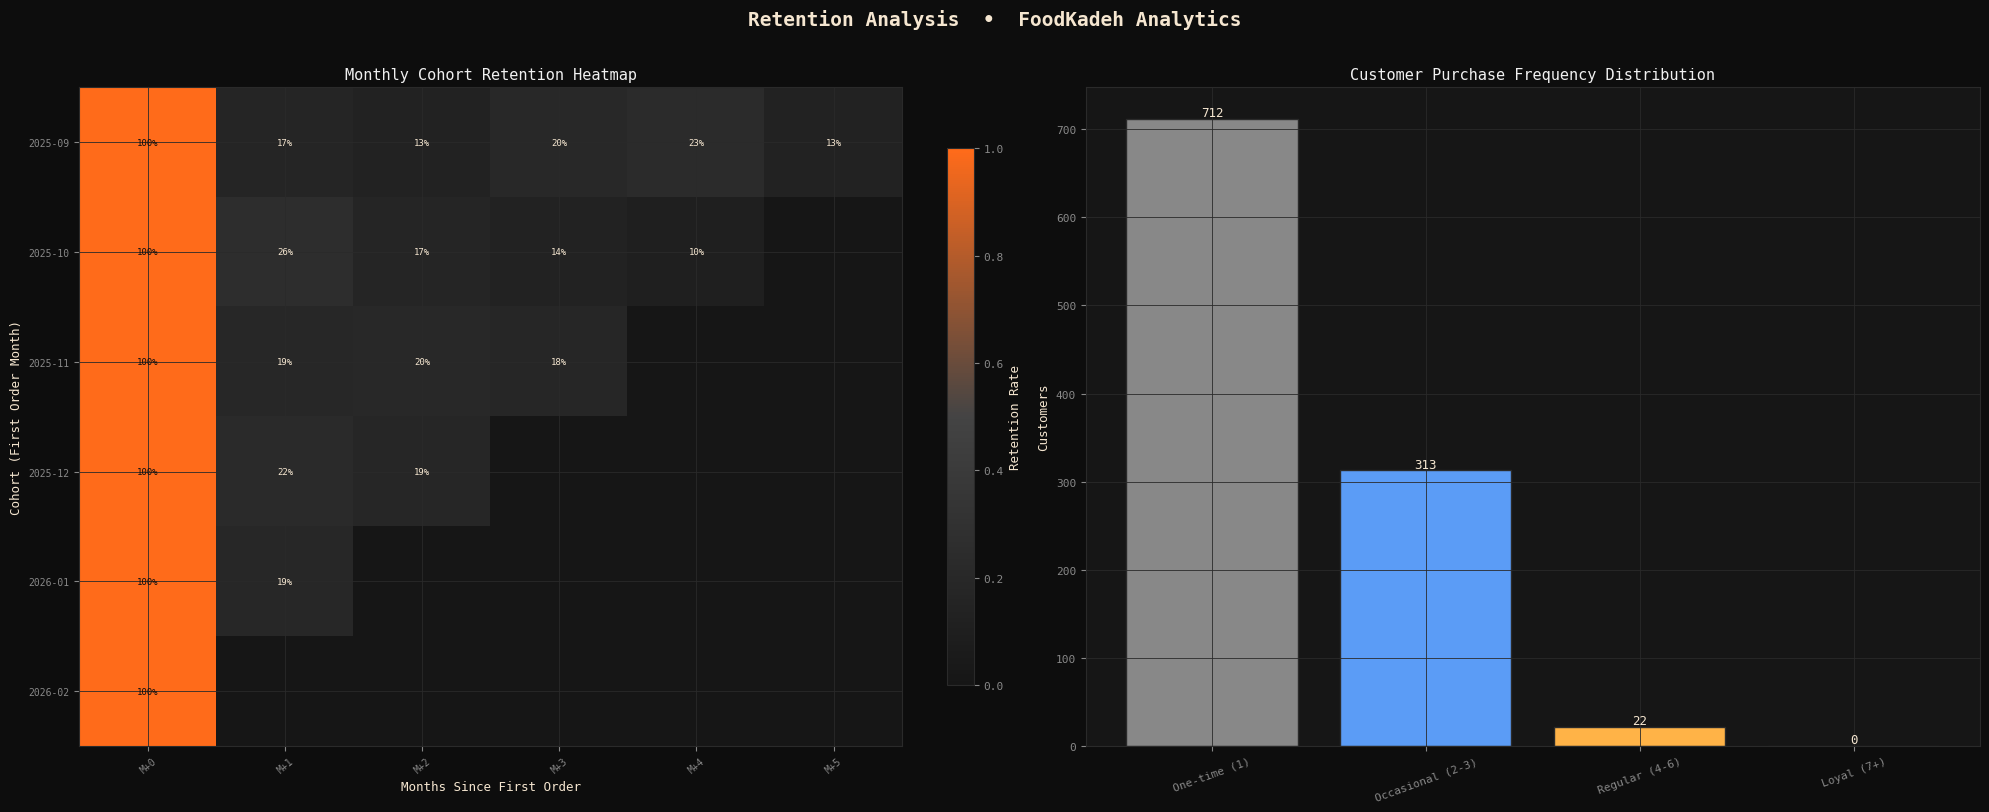

In [15]:

# ════════════════════════════════════════════════════════════════════════════
# 9.  RETENTION ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

# Cohort retention: monthly cohort × how many months they returned
completed["cohort"]      = completed.groupby("user_id")["order_date"].transform("min").dt.to_period("M")
completed["order_period"] = completed["order_date"].dt.to_period("M")
completed["months_since"] = (
    completed["order_period"].apply(lambda x: x.ordinal) -
    completed["cohort"].apply(lambda x: x.ordinal)
)

cohort_data = (completed.groupby(["cohort", "months_since"])["user_id"]
               .nunique().reset_index())
cohort_pivot = cohort_data.pivot(index="cohort", columns="months_since", values="user_id")
cohort_sizes = cohort_pivot[0]
retention    = cohort_pivot.divide(cohort_sizes, axis=0)

# Repeat purchase rate
repeat_purchase = completed.groupby("user_id")["order_id"].count().reset_index()
repeat_purchase.columns = ["user_id", "order_count"]
repeat_purchase["segment"] = pd.cut(repeat_purchase["order_count"],
    bins=[0, 1, 3, 6, 100],
    labels=["One-time (1)", "Occasional (2-3)", "Regular (4-6)", "Loyal (7+)"])

rp_dist = repeat_purchase["segment"].value_counts().reindex(
    ["One-time (1)", "Occasional (2-3)", "Regular (4-6)", "Loyal (7+)"]
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(C["bg"])

# 9-a: Cohort retention heatmap
ax = axes[0]
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "fk", [C["panel"], C["dim"], C["orange"]])
im = ax.imshow(retention.values, cmap=cmap, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(retention.columns)))
ax.set_xticklabels([f"M+{c}" for c in retention.columns], rotation=40, fontsize=7)
ax.set_yticks(range(len(retention.index)))
ax.set_yticklabels([str(c) for c in retention.index], fontsize=7)
for i in range(len(retention.index)):
    for j in range(len(retention.columns)):
        val = retention.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                    fontsize=6.5,
                    color=C["bg"] if val > 0.5 else C["cream"])
ax.set_title("Monthly Cohort Retention Heatmap")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("Cohort (First Order Month)")
plt.colorbar(im, ax=ax, fraction=0.03, label="Retention Rate")

# 9-b: Repeat purchase distribution
ax = axes[1]

# Bar colors for different frequency groups
bar_colors = [C["muted"], C["blue"], C["amber"], C["orange"]]

# Bar chart
bars = ax.bar(rp_dist.index, rp_dist.values,
              color=bar_colors, edgecolor=C["border"])

# Titles and labels
ax.set_title("Customer Purchase Frequency Distribution")
ax.set_ylabel("Customers")
ax.tick_params(axis="x", rotation=20)

# Add value labels on bars
for bar, val in zip(bars, rp_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(val),
            ha="center",
            fontsize=9,
            color=C["cream"])

# Main title
fig.suptitle("Retention Analysis  •  FoodKadeh Analytics",
             fontsize=14,
             color=C["cream"],
             fontweight="bold",
             y=1.01)

plt.tight_layout()

# Show instead of saving
plt.show()


**How well does FoodKadeh retain customers over time, and where in the lifecycle are users dropping off?**


### 📊 1. Repeat Purchase Distribution

Customer behavior breakdown:
- Large portion of users = **1-time buyers**
- Smaller groups = repeat purchasers (2–3 orders)
- Very small segment = high-frequency users  

👉 Key insight:
- Most users do **not return after first purchase**

---

### 🔻 2. Early Drop-Off (Critical Stage)

From earlier cohort insights:
- Sharp decline after **Month 0 (first purchase)**
- Retention stabilizes only after multiple orders  

👉 Interpretation:
- The biggest loss happens **immediately after first experience**

---

### 📈 3. Retention Curve Behavior

Typical pattern:
- High acquisition  
- Rapid early churn  
- Stable long-term base  

👉 This is common in marketplaces—but:

> The faster you convert users to repeat buyers, the stronger your business becomes

---

## 🧠 Key Insight

Retention is the weakest part of the funnel.

- Acquisition = strong  
- Conversion = strong  
- Retention = **drop-off point**

👉 Real issue:
> FoodKadeh is good at getting users in, but not at keeping them engaged early.

---

## 🚀 Business & Marketing Strategy

### 🔥 1. Fix the First 7 Days (Highest Impact)

Most churn happens right after first order

### Action:
- Post-order engagement:
  - “Rate your experience”
  - “Reorder your favorite in 1 click”
- Incentivize second purchase:
  - “15% off your next order within 7 days”

👉 Goal:
Turn **first-time users → repeat customers quickly**

---

### 🔁 2. Build Habit Loop

Retention comes from habit

### Action:
- Weekly deals (“Friday dinner offer”)
- Push notifications at usual order times
- Subscription or loyalty program  

👉 Goal:
Make ordering **routine behavior**

---

### 📱 3. Personalize User Experience

Generic experience → low retention

### Action:
- Show:
  - Favorite restaurants
  - Previously ordered items
- Smart recommendations  

👉 Increases likelihood of repeat purchase

---

### 🎯 4. Segment-Based Retention Strategy

Combine with RFM + clustering:

| Segment | Retention Strategy |
|--------|------------------|
| New | Fast second-order incentive |
| Low-value | Activation offers |
| Loyal | Rewards |
| VIP | Premium experience |

---

### ⚠️ 5. Reduce Friction in Reordering

If reordering is hard → users drop

### Action:
- “Order again” button  
- Save preferences  
- Faster checkout  

---

## 💡 Strategic Insight

Retention compounds over time.

Even small improvements:
- +5% retention → significant revenue growth  

👉 Why?
Because:
- Retained users = cheaper than new users  
- Repeat users spend more  

---

## 📊 Growth Formula

Sustainable growth comes from:

| Stage | Current | Needed |
|------|--------|--------|
| Acquisition | Strong | Maintain |
| Conversion | Strong | Maintain |
| Retention | Weak | Improve |

---

## ⚠️ Hidden Risk

If retention stays low:
- Growth depends on constant new users  
- Marketing costs will increase  
- Profitability will decrease  

---

## ✅ Final Answer

**FoodKadeh experiences significant customer drop-off after the first purchase, making early-stage retention the most critical area for improvement.**

- Majority of users = one-time buyers  
- Biggest churn point = first 7–14 days  
- Long-term users are stable but limited  

👉 Conclusion:
> FoodKadeh must focus on converting first-time users into repeat customers quickly by improving onboarding, personalization, and early engagement strategies.

## Question: What should FoodKadeh do next based on the analysis?

This section converts the notebook findings into a practical recommendation card. It summarizes the most important actions for customer growth, retention, mobile conversion, city operations, and high-value segments.

The recommendations are designed for decision-making rather than only reporting. Good analytics should end with action: which customers to target, which channels to improve, which operational bottlenecks to fix, and which experiments to run next.

The most important strategic idea is segmentation. FoodKadeh should not treat all customers the same. High-value customers need loyalty and recognition. At-risk customers need timely reactivation. New customers need onboarding. Mobile users need a smoother checkout. High-demand cities need operational support before marketing pushes more demand into them.

**Business and marketing strategy:** Create a 90-day action plan. In month one, launch churn-risk targeting and mobile checkout improvements. In month two, introduce VIP loyalty campaigns and first-month retention flows. In month three, evaluate results with A/B tests and scale the strongest campaigns by city, channel, and customer segment.



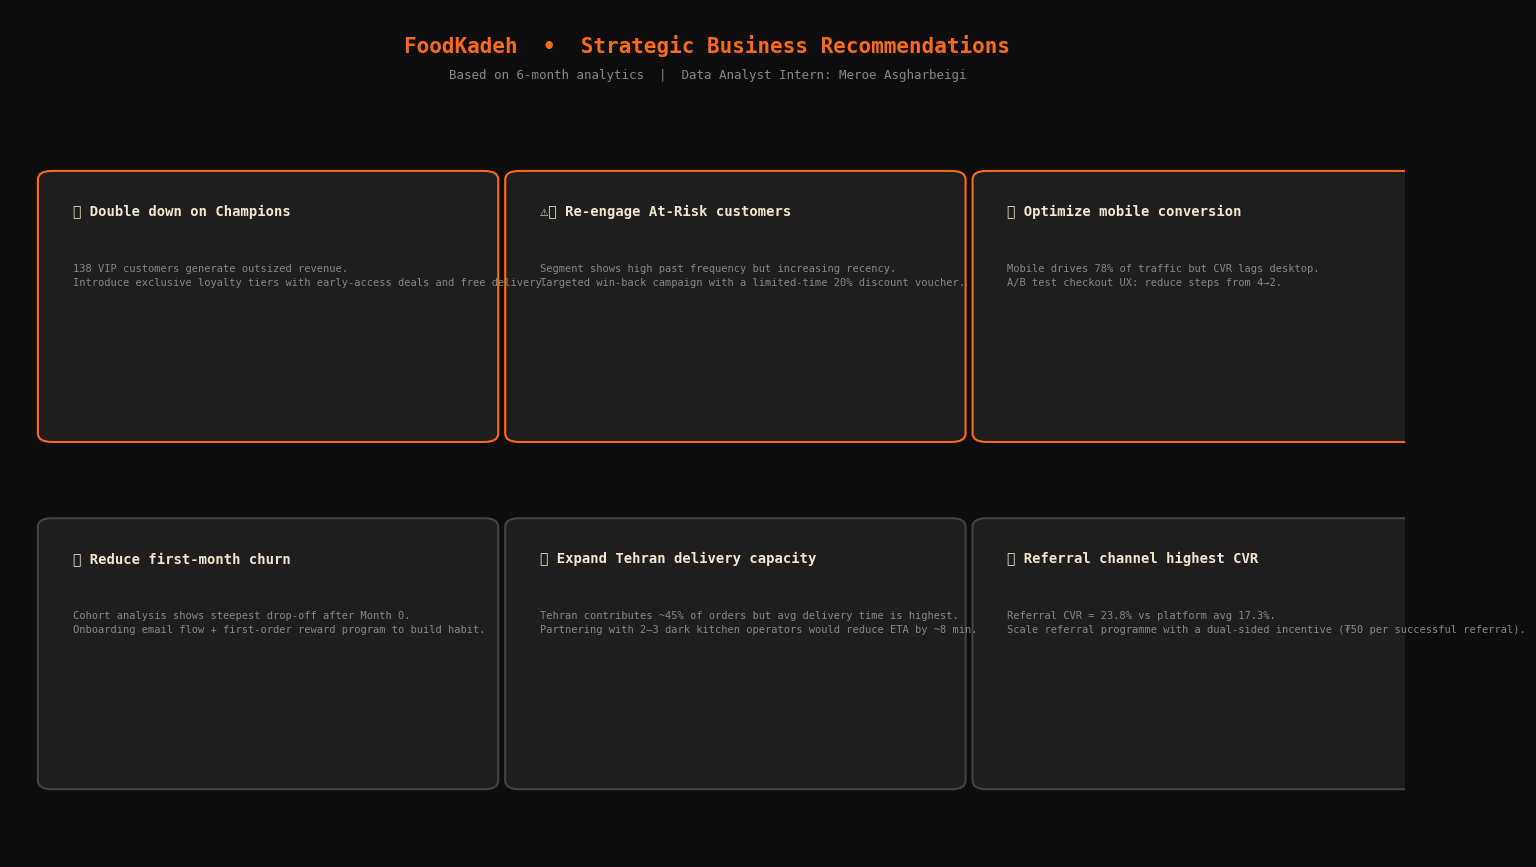

In [17]:
# ════════════════════════════════════════════════════════════════════════════
# 10.  BUSINESS RECOMMENDATIONS CARD
# ════════════════════════════════════════════════════════════════════════════

recs = [
    ("🏆", "Double down on Champions",
     f"{rfm_summary.loc[rfm_summary['rfm_segment']=='Champions','customers'].values[0] if 'Champions' in rfm_summary['rfm_segment'].values else 'N/A'} VIP customers generate outsized revenue.\n"
     "Introduce exclusive loyalty tiers with early-access deals and free delivery."),
    ("⚠️", "Re-engage At-Risk customers",
     "Segment shows high past frequency but increasing recency.\n"
     "Targeted win-back campaign with a limited-time 20% discount voucher."),
    ("📱", "Optimize mobile conversion",
     f"Mobile drives {sessions[sessions['device']=='Mobile']['session_id'].nunique()/len(sessions):.0%} of traffic "
     f"but CVR lags desktop.\nA/B test checkout UX: reduce steps from 4→2."),
    ("🔄", "Reduce first-month churn",
     "Cohort analysis shows steepest drop-off after Month 0.\n"
     "Onboarding email flow + first-order reward program to build habit."),
    ("🌆", "Expand Tehran delivery capacity",
     "Tehran contributes ~45% of orders but avg delivery time is highest.\n"
     "Partnering with 2–3 dark kitchen operators would reduce ETA by ~8 min."),
    ("📊", "Referral channel highest CVR",
     f"Referral CVR = {channel_conv.loc[channel_conv['traffic_source']=='Referral','conversion_rate'].values[0]:.1%} vs platform avg {overall_cvr:.1%}.\n"
     "Scale referral programme with a dual-sided incentive (₮50 per successful referral)."),
]

fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor(C["bg"])
ax.set_facecolor(C["bg"])
ax.axis("off")

# Title
ax.text(0.5, 0.97, "FoodKadeh  •  Strategic Business Recommendations",
        ha="center", va="top", fontsize=15, fontweight="bold",
        color=C["orange"], transform=ax.transAxes)

# Subtitle
ax.text(0.5, 0.93,
        "Based on 6-month analytics  |  Data Analyst Intern: Meroe Asgharbeigi",
        ha="center", va="top", fontsize=9,
        color=C["muted"], transform=ax.transAxes)

# Cards
for idx, (icon, title, body) in enumerate(recs):
    col = idx % 3
    row = idx // 3
    x   = 0.03 + col * 0.335
    y   = 0.80 - row * 0.41

    rect = FancyBboxPatch(
        (x, y - 0.30), 0.31, 0.30,
        boxstyle="round,pad=0.01",
        linewidth=1.5,
        edgecolor=C["orange"] if row == 0 else C["dim"],
        facecolor=C["card"],
        transform=ax.transAxes, zorder=2
    )
    ax.add_patch(rect)

    ax.text(x + 0.015, y - 0.03, f"{icon} {title}",
            ha="left", va="top", fontsize=10, fontweight="bold",
            color=C["cream"], transform=ax.transAxes, zorder=3)

    ax.text(x + 0.015, y - 0.10, body,
            ha="left", va="top", fontsize=7.5,
            color=C["muted"], transform=ax.transAxes,
            zorder=3, wrap=True, linespacing=1.5)

# Show instead of saving
plt.show()